#  NAS Completo: μGA · L-SHADE · Random Search
### Neural Architecture Search con Algoritmos Evolutivos sobre Datasets Tabulares e Imágenes

---


| Algoritmo | Tipo | Descripción |
|-----------|------|-------------|
| **μGA** (Micro Genetic Algorithm) | Evolutivo | AG con población pequeña, cromosoma binario y reinicios de diversidad |
| **L-SHADE** | Diferencial Evolutivo | Self-Adaptive DE con reducción lineal de población (LPSR) |
| **Random Search** | Baseline | Búsqueda aleatoria como línea base de comparación |

### Datasets soportados
- **Tabulares:** Iris, Heart Disease (UCI), Credit Card Fraud, Mammographic Masses
- **Imágenes:** CIFAR-10, TinyFace


---
## 0. Configuración del Entorno

### 0.1 Importaciones

La variable de entorno `PYTORCH_ALLOC_CONF=expandable_segments:True` se configura antes de importar PyTorch para permitir al asignador de memoria GPU fragmentar y reutilizar segmentos de forma más eficiente, evitando errores OOM (Out Of Memory) en GPU.

In [1]:
#!/usr/bin/env python3
# Configuración de asignación de memoria GPU ANTES de importar torch
# 'expandable_segments' permite reutilizar segmentos de memoria fragmentada en GPU
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# ── Utilidades del sistema ──────────────────────────────────────────────────
import os, json, copy, random, warnings, time, hashlib
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# ── Ciencia de datos ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image

# ── Estadística ────────────────────────────────────────────────────────────
from scipy.stats import mannwhitneyu, wilcoxon

# ── Machine Learning (scikit-learn) ────────────────────────────────────────
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, balanced_accuracy_score
)
from sklearn.datasets import load_iris

# ── Deep Learning (PyTorch) ────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights



### 0.2 Detección de Dispositivo (CPU / GPU)

PyTorch detecta automáticamente si hay una GPU CUDA disponible. Si existe, todo el entrenamiento se realizará en GPU para mayor velocidad. Si no, se usa CPU como fallback.

In [2]:
# Selección automática de dispositivo: GPU (CUDA) si está disponible, sino CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {device}")

# Si hay GPU, mostrar su nombre (útil para logs de experimentos)
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("No se detectó GPU — se utilizará CPU.")

Dispositivo activo: cuda
GPU detectada: NVIDIA GeForce RTX 3060


### 0.3 Semilla

La función `set_seed()` fija las semillas de todos los generadores de números aleatorios usados:



In [3]:
# ── Semilla global para reproducibilidad completa ──────────────────────────
SEED = 42

def set_seed(seed=SEED):
    """Fija todas las semillas de aleatoriedad para reproducibilidad."""
    random.seed(seed)               # Python stdlib
    np.random.seed(seed)            # NumPy
    torch.manual_seed(seed)         # PyTorch CPU
    torch.cuda.manual_seed_all(seed)# PyTorch GPU (todos los dispositivos)
    torch.backends.cudnn.deterministic = True   # Operaciones cuDNN deterministas
    torch.backends.cudnn.benchmark = False       # Desactiva autotuner no determinista

set_seed()
print(f" Semilla global fijada: SEED = {SEED}")

# ── Helper para validación cruzada con manejo de clases raras ──────────────
def get_cv_splitter(n_folds: int, stratify: bool = True):
    """
    Devuelve un splitter de CV que maneja clases con pocas muestras.
    
    Intenta primero StratifiedKFold (preserva proporción de clases).
    Si falla (e.g., clase con < n_folds muestras), usa KFold estándar.
    
    Args:
        n_folds:  Número de folds
        stratify: Si True, intenta StratifiedKFold primero
    Returns:
        Objeto splitter (StratifiedKFold o KFold)
    """
    if stratify:
        try:
            return StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
        except:
            pass
    return KFold(n_splits=n_folds, shuffle=True, random_state=SEED)

 Semilla global fijada: SEED = 42


### 0.4 Configuración 


In [4]:
# ── Estilo global de visualizaciones ──────────────────────────────────────
warnings.filterwarnings("ignore")                        # Suprimir warnings menores
plt.style.use("seaborn-v0_8-darkgrid")                  # Tema oscuro con grid
sns.set_palette("husl")                                  # Paleta de colores HSL
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

# ── Directorio de resultados con timestamp único ───────────────────────────
# Cada ejecución genera un subdirectorio propio con fecha y hora exacta
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = Path("muga_dnn_results") / f"experiment_{TIMESTAMP}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)  # Crea el árbol de directorios
print(f"Directorio de resultados: {RESULTS_DIR}")

# ── Directorio de datos ────────────────────────────────────────────────────
DATA_DIR = Path("./data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Directorio de datos: {DATA_DIR}")

Directorio de resultados: muga_dnn_results/experiment_20260412_225243
Directorio de datos: data


### 0.5 Hash para Caché de Arquitecturas

Esta función genera un identificador único (hash MD5, 8 caracteres) a partir de la tupla que describe una arquitectura MLP. Se usa como clave en el sistema de caché (`ArchCache`) para evitar re-evaluar arquitecturas ya calculadas.

In [5]:
def arch_hash(arch: tuple) -> str:
    """
    Genera un hash MD5 de 8 caracteres a partir de una arquitectura.
    
    Convierte la tupla de dimensiones a string, la codifica en bytes
    y aplica MD5. Los primeros 8 caracteres son suficientes para
    evitar colisiones en el espacio de búsqueda NAS.
    
    Ejemplo:
        arch_hash((64, 32))  →  'a3f8c1d2'
        arch_hash((128, 64)) →  'b7e2a4f9'
    
    Args:
        arch: Tupla de enteros representando neuronas por capa
    Returns:
        String hexadecimal de 8 caracteres
    """
    return hashlib.md5(str(arch).encode()).hexdigest()[:8]

# Ejemplo de uso
print(f"Hash de (64, 32): {arch_hash((64, 32))}")
print(f"Hash de (128, 64): {arch_hash((128, 64))}")
print(f"Hash de (64, 32) [repite]: {arch_hash((64, 32))}  ← mismo resultado, determinista")
print(f"Hash de (64, 31) [repite]: {arch_hash((64, 31))}  ← esta cercana pero diferente")
print(f"Hash de (63, 32) [repite]: {arch_hash((63, 32))}  ← esta cercana pero diferente")

Hash de (64, 32): a216c301
Hash de (128, 64): a63143ac
Hash de (64, 32) [repite]: a216c301  ← mismo resultado, determinista
Hash de (64, 31) [repite]: f6135612  ← esta cercana pero diferente
Hash de (63, 32) [repite]: a9ee0c18  ← esta cercana pero diferente


---
## 1. Dataset TinyFace Real 

### ¿Qué es TinyFace?
TinyFace es un dataset de **reconocimiento facial** con imágenes de baja resolución. Se organiza en carpetas, una por identidad (`Training_Set/ID_001/`, `Training_Set/ID_002/`, etc.), con imágenes `.jpg` dentro de cada carpeta.


In [6]:
class TinyFaceTrainDataset(Dataset):
    """
    Dataset PyTorch para TinyFace (Training_Set).
    
    Estructura esperada en disco:
        root/
        └── Training_Set/
            ├── identity_001/
            │   ├── img1.jpg
            │   └── img2.jpg
            ├── identity_002/
            └── ...
    """
    
    def __init__(self, root: Path, transform=None, max_identities: Optional[int] = None):
        """
        Inicializa el dataset escaneando el directorio Training_Set.
        
        Args:
            root:           Path al directorio raíz (debe contener Training_Set/)
            transform:      Transformaciones a aplicar a cada imagen
            max_identities: Si se especifica, carga solo las primeras N identidades
                            (ordenadas alfabéticamente). Útil para pruebas rápidas.
        """
        self.transform = transform
        self.samples = []           # [(ruta_img, label_int), ...]
        self.class_to_idx = {}      # {'nombre_id': 0, 'nombre_id2': 1, ...}
        
        train_dir = root / "Training_Set"
        if not train_dir.exists():
            raise FileNotFoundError(f"No se encontró el directorio: {train_dir}")
        
        # Ordenar identidades alfabéticamente para reproducibilidad
        identities = sorted([d for d in train_dir.iterdir() if d.is_dir()])
        
        # Aplicar límite de identidades si se especificó
        if max_identities is not None:
            identities = identities[:max_identities]
        
        # Construir mapeo nombre→índice y lista de samples
        for idx, identity_dir in enumerate(identities):
            self.class_to_idx[identity_dir.name] = idx
            for img_path in identity_dir.glob("*.jpg"):
                self.samples.append((img_path, idx))
        
        print(f"  TinyFace: {len(identities)} identidades, {len(self.samples)} imágenes totales")
    
    def __len__(self):
        """Retorna el número total de imágenes en el dataset."""
        return len(self.samples)
    
    def __getitem__(self, idx):
        """
        Carga y transforma una imagen por índice.
        
        Returns:
            img:   Tensor de imagen transformado
            label: Entero con el índice de la identidad
        """
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")  # Normaliza a 3 canales siempre
        if self.transform:
            img = self.transform(img)
        return img, label

Número total de clases únicas en el Training_Set: 2570
Promedio de imágenes por clase: 3.04


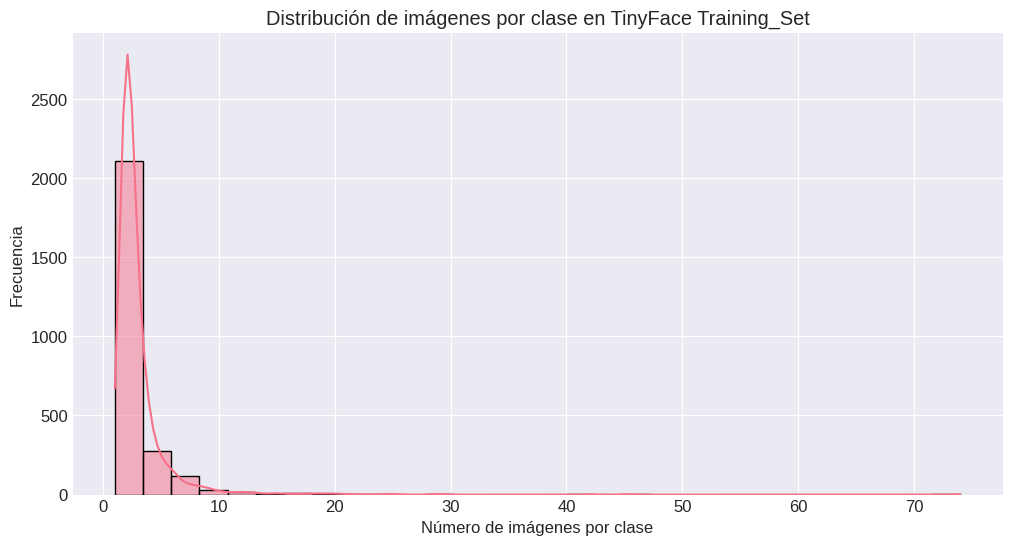

In [7]:
# Clases de tiny face y datos por clase
# data/tinyface/Training_Set/3/3_11.jpg

train_dir = DATA_DIR / "tinyface" / "Training_Set"

# Contar clases unicas en el dataset de entrenamiento y datos por clase
unique_classes = set()
class_counts = {}
for identity_dir in train_dir.iterdir():
    if identity_dir.is_dir():
        unique_classes.add(identity_dir.name)
        class_counts[identity_dir.name] = len(list(identity_dir.glob("*.jpg")))
print(f"Número total de clases únicas en el Training_Set: {len(unique_classes)}")


#promedio de imagenes por clase
avg_images_per_class = sum(class_counts.values()) / len(unique_classes)
print(f"Promedio de imágenes por clase: {avg_images_per_class:.2f}")


#plot de distribución de clases
plt.figure(figsize=(12, 6))
sns.histplot(list(class_counts.values()), bins=30, kde=True)
plt.title("Distribución de imágenes por clase en TinyFace Training_Set")
plt.xlabel("Número de imágenes por clase")
plt.ylabel("Frecuencia")
plt.show()


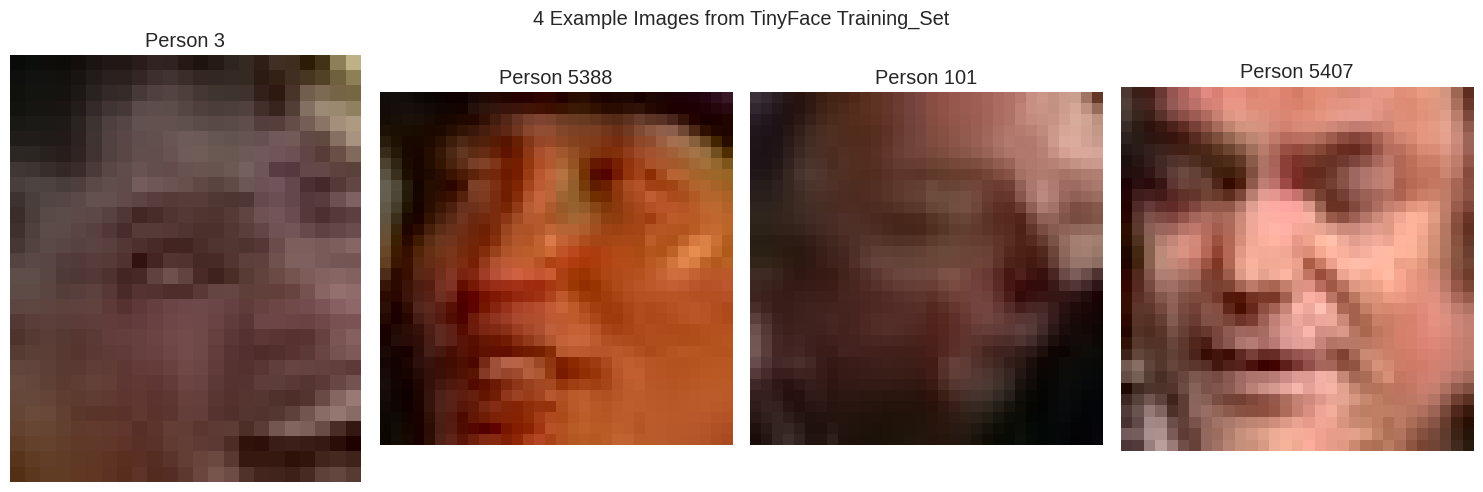

In [8]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Define the path to the Training_Set (adjust if needed)
train_dir = Path("/home/jabonsote/Desktop/Optimizacion/cp microga/data/tinyface/Training_Set")

# Select 5 sample person folders (you can randomize or choose specific ones)
sample_folders = ["3", "5388", "101", "5407"]  # Example IDs; adjust as needed
sample_images = ["3_11.jpg", "5388_1.jpg", "101_1.jpg", "5407_1.jpg"]  # One image per folder

# Create a 1x4 subplot grid
fig, axes = plt.subplots(1, 4, figsize=(15, 5))  # Adjust figsize for better visibility

for i, (folder, img_name) in enumerate(zip(sample_folders, sample_images)):
    img_path = train_dir / folder / img_name
    if img_path.exists():
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Person {folder}")
        axes[i].axis("off")
    else:
        axes[i].text(0.5, 0.5, f"Image not found:\n{folder}/{img_name}", 
                     ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f"Person {folder} (Missing)")
        axes[i].axis("off")

plt.suptitle("4 Example Images from TinyFace Training_Set")
plt.tight_layout()
plt.show()

In [9]:
#size avg of images in tiny face
total_width = 0
total_height = 0
num_images = 0
for identity_dir in train_dir.iterdir():
    if identity_dir.is_dir():
        for img_path in identity_dir.glob("*.jpg"):
            img = Image.open(img_path)
            total_width += img.width
            total_height += img.height
            num_images += 1
avg_width = total_width / num_images
avg_height = total_height / num_images
print(f"Average image size in TinyFace Training_Set: {avg_width:.2f} x {avg_height:.2f} pixels")

Average image size in TinyFace Training_Set: 30.61 x 31.73 pixels


---
## 2. Cargador de Datasets (`DatasetLoader`)

La clase `DatasetLoader` centraliza la carga y preparación de todos los datasets del experimento. Cada método de carga devuelve un diccionario estándar con las mismas claves, lo que permite que el pipeline downstream las procese de forma uniforme.

### Formato de salida estándar (datasets tabulares)
```python
{
    'X': np.ndarray,           # Features (n_samples, n_features)
    'y': np.ndarray,           # Labels enteros
    'feature_names': list,     # Nombres de columnas
    'class_names': list,       # Nombres de clases
    'n_classes': int,
    'n_features': int,
    'n_samples': int,
    'imbalance_ratio': float,  # max_count / min_count
    'type': 'tabular'
}
```

### Formato de salida estándar (datasets de imagen)
```python
{
    'dataset': Dataset,        # torch Dataset con imágenes
    'y': np.ndarray,           # Labels
    'class_names': list,
    'n_classes': int,
    'n_samples': int,
    'imbalance_ratio': float,
    'type': 'image',
    'input_size': tuple        # e.g., (3, 224, 224)
}
```

In [10]:
class DatasetLoader:
    """
    Cargador centralizado de todos los datasets del experimento.
    
    Gestiona descarga automática, parseo y estandarización de formato.
    Todos los datasets de imagen usan el mismo pipeline de transformación
    compatible con ResNet18 (resize 224x224, normalización ImageNet).
    """
    
    def __init__(self, data_dir: Path = DATA_DIR):
        self.data_dir = data_dir
        self.data_dir.mkdir(parents=True, exist_ok=True)
    
    # ── Dataset 1: Iris (sklearn) ──────────────────────────────────────────
    def load_iris(self) -> Dict[str, Any]:
        """
        Carga el dataset Iris directamente desde scikit-learn.
        
        - 150 muestras, 4 features (longitud/ancho de sépalo y pétalo)
        - 3 clases: setosa, versicolor, virginica
        - Dataset perfectamente balanceado (50 muestras por clase)
        """
        data = load_iris()
        X = data.data.astype(np.float32)
        y = data.target.astype(np.int64)
        unique, counts = np.unique(y, return_counts=True)
        return dict(
            X=X, y=y,
            feature_names=list(data.feature_names),
            class_names=list(data.target_names),
            n_classes=len(unique),
            n_features=X.shape[1],
            n_samples=len(y),
            imbalance_ratio=float(max(counts) / min(counts)),
            type="tabular"
        )
    
    # ── Dataset 2: Heart Disease (UCI) ─────────────────────────────────────
    def load_heart_disease(self) -> Dict[str, Any]:
        """
        Carga el dataset Heart Disease de UCI (processed.cleveland.data).
        
        - ~303 muestras, 13 features clínicos (edad, sexo, presión, colesterol, etc.)
        - Clasificación binaria: sin enfermedad (0) vs con enfermedad (>0)
        - Descarga automática desde UCI si no existe localmente.
        - Maneja archivos con y sin cabecera, y valores '?' como NaN.
        
        Preprocesamiento:
            - Binariza la columna target: 0 = sin enfermedad, 1 = con enfermedad
            - Elimina filas con valores NaN (dropna)
        """
        local_path = self.data_dir / "heart.csv"
        if not local_path.exists():
            import urllib.request
            url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
            urllib.request.urlretrieve(url, local_path)
        
        # Detectar si el archivo tiene cabecera o no
        with open(local_path, 'r') as f:
            first_line = f.readline().strip()
        has_header = any(c.isalpha() for c in first_line)  # True si contiene letras
        
        if has_header:
            df = pd.read_csv(local_path, na_values="?")
        else:
            cols = ["age","sex","cp","trestbps","chol","fbs","restecg",
                    "thalach","exang","oldpeak","slope","ca","thal","num"]
            df = pd.read_csv(local_path, header=None, names=cols, na_values="?")
        
        df = df.dropna()  # Eliminar filas con valores faltantes
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = (df.iloc[:, -1].values > 0).astype(np.int64)  # Binarización del target
        unique, counts = np.unique(y, return_counts=True)
        return dict(
            X=X, y=y,
            feature_names=[f"feat_{i}" for i in range(X.shape[1])],
            class_names=["No Disease", "Disease"],
            n_classes=2, n_features=X.shape[1], n_samples=len(y),
            imbalance_ratio=float(max(counts) / min(counts)),
            type="tabular"
        )
    
    # ── Dataset 3: Credit Card Fraud ───────────────────────────────────────
    def load_credit_card_fraud(self) -> Dict[str, Any]:
        """
        Carga el dataset de detección de fraude con tarjetas de crédito.
        
        - ~284.807 transacciones originales (usamos 20% para eficiencia)
        - 28 features PCA anonimizados (V1-V28) + Amount
        - Binario: Normal (0) vs Fraude (1)
        - Altamente desbalanceado: ~0.17% son fraudes (IR ≈ 578)
        - Se descarga automáticamente desde Google Storage si no existe.
        
        Decisiones de diseño:
            - Se usa sample(frac=0.2) para reducir tiempo de cómputo
            - Se eliminan columnas 'Time' (irrelevante) y 'Class' (target)
        """
        path = self.data_dir / "creditcard.csv"
        if not path.exists():
            import urllib.request
            url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
            print("  Descargando Credit Card Fraud dataset...")
            urllib.request.urlretrieve(url, path)
        
        # Muestra el 20% para reducir tiempo de experimento
        df = pd.read_csv(path).sample(frac=0.2, random_state=SEED)
        X = df.drop(["Time", "Class"], axis=1).values.astype(np.float32)
        y = df["Class"].values.astype(np.int64)
        unique, counts = np.unique(y, return_counts=True)
        ir = float(max(counts) / max(min(counts), 1))  # Evitar división por cero
        return dict(
            X=X, y=y,
            feature_names=[f"V{i}" for i in range(1, X.shape[1] + 1)],
            class_names=["Normal", "Fraud"],
            n_classes=2, n_features=X.shape[1], n_samples=len(y),
            imbalance_ratio=ir, type="tabular"
        )
    
    # ── Dataset 4: Mammographic Masses ────────────────────────────────────
    def load_mammographic_masses(self) -> Dict[str, Any]:
        """
        Carga el dataset de masas mamográficas (UCI).
        
        - ~830 muestras, 5 atributos clínicos (BI-RADS, edad, forma, margen, densidad)
        - Binario: Benigno (0) vs Maligno (1)
        - Los valores '?' se tratan como NaN y se eliminan con dropna.
        
        Rutas buscadas:
            1. data/mammographic_masses.data
            2. data/mammographic+mass/mammographic_masses.data
        """
        local_path = self.data_dir / "mammographic_masses.data"
        if not local_path.exists():
            # Ruta alternativa si el usuario descomprimió en subcarpeta
            alt_path = self.data_dir / "mammographic+mass" / "mammographic_masses.data"
            if alt_path.exists():
                local_path = alt_path
            else:
                raise FileNotFoundError("No se encuentra mammographic_masses.data")
        
        df = pd.read_csv(local_path, header=None, na_values="?").dropna()
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int64)
        unique, counts = np.unique(y, return_counts=True)
        return dict(
            X=X, y=y,
            feature_names=[f"feat_{i}" for i in range(X.shape[1])],
            class_names=["Benign", "Malignant"],
            n_classes=2, n_features=X.shape[1], n_samples=len(y),
            imbalance_ratio=float(max(counts) / min(counts)),
            type="tabular"
        )
    
    # ── Dataset 5: CIFAR-10 ────────────────────────────────────────────────
    def load_cifar10(self) -> Dict[str, Any]:
        """
        Carga el dataset CIFAR-10 (torchvision).
        
        - 60.000 imágenes 32x32 RGB (10 clases: avión, auto, pájaro, gato...)
        - Se combinan splits train+test en un único dataset para usar
          la división train/test propia del experimento.
        - Transformación:
            1. Resize(224): Escala a resolución compatible con ResNet18
            2. ToTensor(): [0,255] uint8 → [0,1] float32
            3. Normalize: Normaliza con media=[0.485,0.456,0.406] y
               std=[0.229,0.224,0.225] (estadísticas de ImageNet)
        """
        tf = transforms.Compose([
            transforms.Resize(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        train = torchvision.datasets.CIFAR10(str(self.data_dir), train=True,  download=True, transform=tf)
        test  = torchvision.datasets.CIFAR10(str(self.data_dir), train=False, download=True, transform=tf)
        full  = torch.utils.data.ConcatDataset([train, test])  # Union de ambos splits
        y = np.array(train.targets + test.targets)
        unique, counts = np.unique(y, return_counts=True)
        return dict(
            dataset=full, y=y,
            class_names=train.classes,
            n_classes=10, n_samples=len(full),
            class_distribution=dict(zip(unique.tolist(), counts.tolist())),
            imbalance_ratio=1.0,  # CIFAR-10 está perfectamente balanceado
            type="image", input_size=(3, 224, 224)
        )
    
    # ── Dataset 6: TinyFace ────────────────────────────────────────────────
    def load_tinyface(self, max_identities: int = 200) -> Dict[str, Any]:
        """
        Carga el dataset TinyFace para reconocimiento facial.
        
        - Por defecto carga hasta 200 identidades para controlar tiempo
        - Las imágenes se redimensionan a 224x224 para ResNet18
        - Misma normalización ImageNet que CIFAR-10
        
        Args:
            max_identities: Número máximo de identidades a cargar
        """
        tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        root = self.data_dir / "tinyface"
        dataset = TinyFaceTrainDataset(root, transform=tf, max_identities=max_identities)
        y = np.array([s[1] for s in dataset.samples])
        unique, counts = np.unique(y, return_counts=True)
        n_classes = len(unique)
        return dict(
            dataset=dataset, y=y,
            class_names=[f"ID_{i}" for i in range(n_classes)],
            n_classes=n_classes, n_samples=len(dataset),
            imbalance_ratio=float(max(counts) / max(min(counts), 1)),
            type="image", input_size=(3, 224, 224)
        )
    
    # ── Carga de todos los datasets ────────────────────────────────────────
    def load_all(self) -> Dict[str, Dict[str, Any]]:
        """
        Intenta cargar todos los datasets en orden.
        
        Los errores por dataset faltante se imprimen como advertencias
        y el dataset se omite (el experimento continúa con los disponibles).
        
        Orden de carga:
            tinyface → cifar10 → iris → heart → credit → mammo
        """
        datasets = {}
        loaders = [
            ("tinyface", self.load_tinyface),
            ("cifar10",  self.load_cifar10),
            ("iris",     self.load_iris),
            ("heart",    self.load_heart_disease),
            ("credit",   self.load_credit_card_fraud),
            ("mammo",    self.load_mammographic_masses),
        ]
        for name, fn in loaders:
            print(f"  Cargando {name}...")
            try:
                datasets[name] = fn()
            except Exception as e:
                print(f"    Error en {name}: {e}")
        return datasets

---
## 3. Modelos: ResNet18 Extractor + MLP Clasificador


En lugar de entrenar CNNs completas end-to-end (costoso), se usa **transfer learning** con ResNet18 preentrenado:

```
Imagen (224×224) - ResNet18 (congelado) - Embedding 512-dim - MLP (optimizado por NAS)
```

Esto reduce el problema de NAS a buscar la arquitectura MLP óptima en el espacio de embeddings.

### `ResNet18Extractor`
- Usa ResNet18 con pesos preentrenados en **ImageNet1K**.
- Elimina la capa clasificadora final (fully connected de 1000 clases).
- El resultado es un vector de **512 dimensiones** por imagen.
- Con `freeze=True`, todos los parámetros se congelan (`requires_grad=False`), reduciendo el coste computacional.

### `MLPClassifier`
Arquitectura MLP con capas densas. Cada capa hidden sigue el patrón:
```
Linear - BatchNorm1d - ReLU - Dropout(0.4)
```
- **BatchNorm:** Estabiliza el entrenamiento normalizando activaciones.
- **Dropout(0.4):** Regularización para evitar sobreajuste (40% de neuronas desactivadas aleatoriamente).
- La capa final es un `Linear` sin activación (logits para CrossEntropyLoss).

### `extract_features`
Función auxiliar que pasa un DataLoader completo por el extractor y devuelve arrays NumPy con todos los embeddings y labels.

In [11]:
# ── Extractor de features basado en ResNet18 preentrenado ──────────────────
class ResNet18Extractor(nn.Module):
    """
    Extractor de features usando ResNet18 preentrenado en ImageNet.
    
    Elimina la capa de clasificación final y produce embeddings de 512 dim.
    Con freeze=True, los pesos no se actualizan durante el entrenamiento.
    
    Arquitectura interna:
        Conv → BN → ReLU → MaxPool → [ResBlocks x4] → AvgPool → Flatten(512d)
    """
    
    def __init__(self, freeze: bool = True):
        """
        Args:
            freeze: Si True, congela todos los parámetros del extractor.
                    Esto hace que el modelo actúe puramente como transformador
                    fijo, sin actualizar pesos durante backprop.
        """
        super().__init__()
        # Cargar ResNet18 con pesos oficiales de ImageNet
        base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        # Quitar la última capa (Linear 512→1000 de clasificación)
        # children()[:-1] devuelve todo excepto el FC final
        self.features = nn.Sequential(*list(base.children())[:-1])
        self.feature_dim = 512  # Dimensión de salida después del AvgPool global
        
        if freeze:
            for p in self.features.parameters():
                p.requires_grad = False  # Congela gradientes → no se actualizan
    
    def forward(self, x):
        """Extrae embedding: [B,3,224,224] → [B,512]"""
        return self.features(x).flatten(1)  # flatten a partir de dim 1


# ── Clasificador MLP dinámico ──────────────────────────────────────────────
class MLPClassifier(nn.Module):
    """
    Clasificador MLP configurable cuya arquitectura es el objetivo de NAS.
    
    Estructura por capa hidden:
        Linear(prev_dim → h) → BatchNorm1d(h) → ReLU → Dropout(dropout)
    
    Última capa: Linear(last_h → n_classes) [sin activación, para CrossEntropy]
    """
    
    def __init__(self, input_dim: int, hidden_dims: List[int], n_classes: int, dropout: float = 0.4):
        """
        Args:
            input_dim:   Dimensión de entrada (512 para features ResNet, ≥4 para tabular)
            hidden_dims: Lista de neuronas por capa, ej [64, 32] → 2 capas hidden
            n_classes:   Número de clases de salida
            dropout:     Tasa de Dropout para regularización (default 0.4 = 40%)
        """
        super().__init__()
        layers = []
        prev = input_dim
        
        # Construir capas hidden dinámicamente según hidden_dims
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),        # Transformación lineal
                nn.BatchNorm1d(h),          # Normalización de batch
                nn.ReLU(inplace=True),      # Activación no lineal (in-place ahorra memoria)
                nn.Dropout(dropout)         # Regularización por dropout
            ]
            prev = h
        
        # Capa de clasificación final (sin activación)
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
        self.hidden_dims = hidden_dims  # Guardar para referencia
    
    def forward(self, x):
        return self.net(x)
    
    def n_params(self):
        """Cuenta los parámetros entrenables del modelo."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Función para extraer features de un DataLoader completo ───────────────
def extract_features(
    extractor: ResNet18Extractor,
    loader: DataLoader
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Pasa todos los batches de un DataLoader por el extractor y
    devuelve los embeddings y etiquetas como arrays NumPy.
    
    Usa torch.no_grad() para desactivar el cálculo de gradientes,
    reduciendo el uso de memoria y acelerando la extracción.
    
    Args:
        extractor: Modelo ResNet18 congelado
        loader:    DataLoader con imágenes
    Returns:
        feats:  Array (n_samples, 512) con embeddings
        labels: Array (n_samples,) con etiquetas enteras
    """
    extractor.eval()
    feats, labels = [], []
    with torch.no_grad():
        for imgs, ys in tqdm(loader, desc="Extrayendo features", leave=False):
            feats.append(extractor(imgs.to(device)).cpu().numpy())
            labels.append(ys.numpy())
    return np.vstack(feats), np.concatenate(labels)


---
## 4. Caché de Arquitecturas (`ArchCache`)

El sistema de caché evita re-evaluar arquitecturas MLP que ya han sido evaluadas, lo que es importante cuando los algoritmos de búsqueda exploran el mismo punto múltiples veces (frecuente en GA y DE).


In [12]:
class ArchCache:
    """
    Caché persistente de evaluaciones de arquitecturas NAS.
    
    Persiste en un CSV para que las evaluaciones sobrevivan entre runs.
    Usa hash MD5 de la arquitectura como clave de búsqueda O(1).
    
    Formato del CSV:
        hash,fitness,arch
        a3f8c1d2,0.9523,"(64, 32)"
        b7e2a4f9,0.9134,"(128, 64)"
    """
    
    def __init__(self, cache_path: Path):
        """
        Carga el caché existente desde disco (si existe).
        
        Args:
            cache_path: Ruta al archivo CSV del caché
        """
        self.path = Path(cache_path)
        self._data: Dict[str, dict] = {}  # Almacén en memoria {hash: record}
        
        if self.path.exists():
            try:
                df = pd.read_csv(self.path)
                for _, row in df.iterrows():
                    arch_str = row.get('arch', '')
                    if arch_str:
                        try:
                            # Soporta formato tuple: (64, 32) y lista: [64, 32]
                            if arch_str.startswith('('):
                                arch = eval(arch_str)  # Tupla Python
                            else:
                                parts = arch_str.strip('[]').split(',')
                                arch = tuple(int(float(p.strip())) for p in parts if p.strip())
                            h = arch_hash(arch)
                            self._data[h] = row.to_dict()
                        except Exception:
                            continue  # Fila corrupta → omitir
                print(f"  [Cache] Cargadas {len(self._data)} evaluaciones desde disco")
            except Exception as e:
                print(f"  [Cache] Error al cargar: {e} → Caché vacío")
                self._data = {}
    
    def get(self, arch: tuple) -> Optional[dict]:
        """
        Busca una arquitectura en el caché.
        
        Args:
            arch: Tupla de dimensiones de la arquitectura
        Returns:
            Diccionario con 'fitness' y metadatos, o None si no está en caché
        """
        h = arch_hash(arch)
        data = self._data.get(h)
        if data is not None and "fitness" in data:
            data["fitness"] = float(data["fitness"])  # Garantizar tipo float
        return data
    
    def put(self, arch: tuple, record: dict):
        """
        Guarda una nueva evaluación en memoria y en disco.
        Solo escribe si la arquitectura no está ya en caché.
        
        Args:
            arch:   Tupla de arquitectura
            record: Diccionario {'fitness': float, 'arch': str, ...}
        """
        h = arch_hash(arch)
        if h not in self._data:  # Solo guardar si es nueva
            record['hash'] = h
            self._data[h] = record
            # Append al CSV (eficiente: no reescribe todo el archivo)
            pd.DataFrame([record]).to_csv(
                self.path, mode='a',
                header=not self.path.exists(),  # Cabecera solo si es nuevo archivo
                index=False
            )

---
## 5. Micro Algoritmo Genético (`MicroGA`)

### ¿Qué es un μGA (Micro Genetic Algorithm)?
Un AG con **población muy pequeña** (default: 4 individuos) que compensa su limitada diversidad con **reinicios de población** cuando la diversidad cae bajo un umbral (distancia de Hamming normalizada < 0.05).

### Codificación del genotipo (Cromosoma binario)
Cada individuo es un vector binario que codifica **2 capas hidden** mediante representación binaria:

```
n_bits = ceil(log2(max_n - min_n + 1))   # bits necesarios para representar el rango
chrom_len = 2 * n_bits                    # 2 capas × n_bits cada una

Decodificación:
  bits → entero val → neurons = min_n + val/max_val × (max_n - min_n)
```

### Operadores evolutivos

| Operador | Descripción |
|----------|-------------|
| **Selección por torneo** | Compara pares aleatorios; en empate, gana el de menor tamaño |
| **Cruce de 2 puntos** | Con probabilidad `pc=0.9`, se intercambian segmentos entre dos padres |
| **Reinicio de diversidad** | Si distancia Hamming media < umbral, reinicia toda la población excepto el élite |

### Función de fitness
Promedio de `balanced_accuracy_score` (o accuracy) en validación cruzada K-Fold. Si `penalize_zero_recall=True` y alguna clase tiene recall=0, se descuenta 0.5 al fitness.

### Proxy de evaluación
Con `proxy_fraction < 1.0`, se evalúa en un subconjunto aleatorio del training set, reduciendo el tiempo de evaluación de fitness (el modelo base usa la muestra completa al final).

In [13]:
class MicroGA:
    """
    Micro Algoritmo Genético (μGA) para NAS de arquitecturas MLP de 2 capas.
    
    Representa cada arquitectura como un cromosoma binario de longitud
    2*n_bits donde cada mitad codifica el número de neuronas de una capa.
    La diversidad se controla mediante distancia de Hamming normalizada
    y se realizan reinicios con élite cuando la población converge.
    """
    
    def __init__(
        self,
        input_dim: int,
        n_classes: int,
        min_n: int = 8,
        max_n: int = 128,
        pop_size: int = 4,
        max_gen: int = 20,
        pc: float = 0.9,
        hamming_threshold: float = 0.05,
        n_folds: int = 3,
        train_epochs: int = 10,
        batch_size: int = 32,
        cache: Optional[ArchCache] = None,
        proxy_fraction: float = 1.0,
        use_balanced: bool = True,
        penalize_zero_recall: bool = False
    ):
        """
        Args:
            input_dim:             Dimensión de entrada de los datos
            n_classes:             Número de clases
            min_n / max_n:         Rango de neuronas por capa
            pop_size:              Tamaño de población (4 para μGA clásico)
            max_gen:               Generaciones máximas
            pc:                    Probabilidad de cruce (0.9)
            hamming_threshold:     Umbral de diversidad Hamming para reiniciar
            n_folds:               Folds para validación cruzada
            train_epochs:          Épocas de entrenamiento por evaluación
            batch_size:            Tamaño de batch en evaluaciones
            cache:                 Cache de evaluaciones previas
            proxy_fraction:        Fracción del dataset para evaluación rápida
            use_balanced:          Si True, usa balanced_accuracy como fitness
            penalize_zero_recall:  Si True, penaliza -0.5 por clase con recall=0
        """
        self.input_dim = input_dim; self.n_classes = n_classes
        self.min_n = min_n; self.max_n = max_n
        self.pop_size = pop_size; self.max_gen = max_gen
        self.pc = pc; self.hamming_threshold = hamming_threshold
        self.n_folds = n_folds; self.train_epochs = train_epochs; self.batch_size = batch_size
        self.cache = cache; self.proxy_fraction = proxy_fraction
        self.use_balanced = use_balanced; self.penalize_zero_recall = penalize_zero_recall
        
        # Calcular longitud del cromosoma
        # n_bits = bits necesarios para representar [min_n, max_n]
        self.n_bits = int(np.ceil(np.log2(max_n - min_n + 1)))
        self.chrom_len = 2 * self.n_bits  # 2 capas
        
        # Historial de evolución para graficar
        self.history = {"gen": [], "best_fit": [], "avg_fit": [], "diversity": [], "best_arch": []}
    
    def _decode(self, chrom: np.ndarray) -> List[int]:
        """
        Decodifica un cromosoma binario a lista de neuronas por capa.
        
        Para cada capa:
            1. Extrae n_bits bits como array [0,1,...]
            2. Convierte a entero con repr. binaria
            3. Mapea linealmente al rango [min_n, max_n]
        """
        dims = []
        max_val = (1 << self.n_bits) - 1  # 2^n_bits - 1 = valor máximo representable
        for i in range(2):  # 2 capas
            bits = chrom[i * self.n_bits:(i + 1) * self.n_bits]
            val = int("".join(bits.astype(str)), 2)  # Binario → entero
            neurons = int(self.min_n + val / max_val * (self.max_n - self.min_n))
            dims.append(max(neurons, self.min_n))
        return dims
    
    def _init_pop(self):
        """Inicializa población aleatoria binaria de tamaño (pop_size, chrom_len)."""
        return np.random.randint(0, 2, (self.pop_size, self.chrom_len))
    
    def _evaluate(self, chrom: np.ndarray, X: np.ndarray, y: np.ndarray) -> float:
        """
        Evalúa un cromosoma mediante entrenamiento + CV.
        
        Flujo:
        1. Decodifica cromosoma → arquitectura
        2. Busca en caché (retorna si existe)
        3. Opcionalmente submuestrea datos (proxy_fraction)
        4. Hace K-Fold CV con StratifiedKFold (fallback a KFold)
        5. Entrena MLP en cada fold, mide balanced_accuracy en validación
        6. Promedia scores → fitness
        7. Penaliza si hay clases con recall=0 (desbalanceo extremo)
        8. Guarda en caché
        """
        from sklearn.metrics import balanced_accuracy_score, recall_score
        from sklearn.model_selection import KFold
        
        hidden = self._decode(chrom)
        arch = tuple(hidden)
        
        # ── Hit de caché ──────────────────────────────────────────────────
        if self.cache:
            cached = self.cache.get(arch)
            if cached:
                fit = cached.get("fitness", 0.0)
                return float(fit) if isinstance(fit, str) else fit
        
        # ── Submuestreo proxy para evaluación rápida ───────────────────
        if self.proxy_fraction < 1.0:
            try:
                X_eval, _, y_eval, _ = train_test_split(
                    X, y, train_size=self.proxy_fraction, stratify=y, random_state=SEED
                )
            except ValueError:  # Clases con pocas muestras
                X_eval, _, y_eval, _ = train_test_split(
                    X, y, train_size=self.proxy_fraction, stratify=None, random_state=SEED
                )
        else:
            X_eval, y_eval = X, y
        
        # ── Validación cruzada con fallback ────────────────────────────
        try:
            skf = StratifiedKFold(n_splits=self.n_folds, shuffle=True, random_state=SEED)
            splits = list(skf.split(X_eval, y_eval))
        except ValueError:
            skf = KFold(n_splits=self.n_folds, shuffle=True, random_state=SEED)
            splits = list(skf.split(X_eval))
        
        scores, min_recalls = [], []
        for tr, va in splits:
            model = MLPClassifier(self.input_dim, hidden, self.n_classes).to(device)
            Xtr = torch.tensor(X_eval[tr], dtype=torch.float32).to(device)
            ytr = torch.tensor(y_eval[tr], dtype=torch.long).to(device)
            Xva = torch.tensor(X_eval[va], dtype=torch.float32).to(device)
            loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=self.batch_size, shuffle=True, num_workers=0)
            
            opt_m = optim.Adam(model.parameters(), lr=1e-3)
            crit = nn.CrossEntropyLoss()
            model.train()
            for _ in range(self.train_epochs):
                for bx, by in loader:
                    opt_m.zero_grad()
                    crit(model(bx), by).backward()
                    opt_m.step()
            
            model.eval()
            with torch.no_grad():
                pred = model(Xva).argmax(1).cpu().numpy()
                score = (
                    balanced_accuracy_score(y_eval[va], pred)
                    if self.use_balanced
                    else accuracy_score(y_eval[va], pred)
                )
                scores.append(score)
                if self.penalize_zero_recall:
                    rec = recall_score(y_eval[va], pred, average=None, zero_division=0)
                    min_recalls.append(np.min(rec))
        
        fitness = float(np.mean(scores))
        
        # ── Penalización por recall cero (desbalanceo extremo) ─────────
        if self.penalize_zero_recall and len(min_recalls) > 0 and np.mean(min_recalls) == 0.0:
            fitness -= 0.5  # Penalización severa
        
        if self.cache:
            self.cache.put(arch, {"fitness": fitness, "arch": str(arch)})
        return fitness
    
    def _tournament(self, pop, fit):
        """
        Selección por torneo binario.
        
        Para cada slot de la nueva población:
            - Elige 2 individuos al azar
            - El de mayor fitness gana
            - En empate, gana el de menor suma de neuronas (parsimonia)
        """
        n = len(pop)
        selected = []
        for _ in range(n):
            a, b = np.random.choice(n, 2, replace=False)
            if fit[a] > fit[b]:
                selected.append(pop[a])
            elif fit[b] > fit[a]:
                selected.append(pop[b])
            else:  # Empate: preferir menor tamaño (parsimonia)
                da, db = self._decode(pop[a]), self._decode(pop[b])
                selected.append(pop[a] if sum(da) <= sum(db) else pop[b])
        return np.array(selected)
    
    def _crossover(self, parents):
        """
        Cruce de 2 puntos.
        
        Para cada par de padres consecutivos:
            Con prob. pc: selecciona 2 puntos de corte aleatorios y
            intercambia el segmento central entre ambos padres.
        """
        offspring = []
        for i in range(0, len(parents), 2):
            p1 = parents[i]
            p2 = parents[(i + 1) % len(parents)]
            if np.random.rand() < self.pc and self.chrom_len > 2:
                pts = sorted(np.random.choice(self.chrom_len - 1, 2, replace=False))
                c1 = np.concatenate([p1[:pts[0]], p2[pts[0]:pts[1]], p1[pts[1]:]])
                c2 = np.concatenate([p2[:pts[0]], p1[pts[0]:pts[1]], p2[pts[1]:]])
            else:
                c1, c2 = p1.copy(), p2.copy()  # Sin cruce
            offspring += [c1, c2]
        return np.array(offspring[:len(parents)])
    
    def _diversity(self, pop):
        """
        Calcula diversidad como distancia de Hamming normalizada promedio
        entre todos los pares de individuos de la población.
        
        Rango: [0.0, 1.0] donde 0.0 = todos idénticos, 1.0 = maximalmente distintos.
        """
        n = len(pop)
        dists = [
            np.sum(pop[i] != pop[j]) / self.chrom_len
            for i in range(n) for j in range(i + 1, n)
        ]
        return float(np.mean(dists)) if dists else 0.0
    
    def _restart(self, pop, fit):
        """
        Reinicio con élite: preserva el mejor individuo y regenera el resto.
        
        Mantiene la mejor solución encontrada y reinicia el resto de la
        población aleatoriamente, restaurando diversidad.
        """
        elite = pop[np.argmax(fit)].copy()
        new_pop = np.random.randint(0, 2, (self.pop_size - 1, self.chrom_len))
        return np.vstack([elite, new_pop])
    
    def optimize(self, X, y):
        """
        Ejecuta el μGA completo.
        
        Algoritmo por generación:
            1. Selección por torneo
            2. Cruce de 2 puntos
            3. Evaluar descendencia
            4. (μ+λ) selection: combinar padres+hijos, mantener top pop_size
            5. Actualizar mejor global
            6. Verificar diversidad → reiniciar si < umbral
            7. Registrar historial
        
        Returns:
            best_arch: Lista de neuronas [L1, L2]
            best_fit:  Fitness del mejor individuo
            history:   Diccionario con registros por generación
        """
        pop = self._init_pop()
        fit = np.array([self._evaluate(ind, X, y) for ind in pop])
        best_idx = np.argmax(fit)
        best_fit, best_chrom = fit[best_idx], pop[best_idx].copy()
        
        pbar = tqdm(range(self.max_gen), desc="μGA")
        for g in pbar:
            # Operadores evolutivos
            parents = self._tournament(pop, fit)
            offspring = self._crossover(parents)
            off_fit = np.array([self._evaluate(ind, X, y) for ind in offspring])
            
            # (μ+λ): Combinar y seleccionar los mejores
            pool = np.vstack([pop, offspring])
            pool_fit = np.concatenate([fit, off_fit])
            order = np.argsort(pool_fit)[::-1]  # Ordenar de mayor a menor fitness
            pop = pool[order[:self.pop_size]]
            fit = pool_fit[order[:self.pop_size]]
            
            # Actualizar mejor global
            if fit[0] > best_fit:
                best_fit, best_chrom = fit[0], pop[0].copy()
            
            # Control de diversidad con reinicio
            div = self._diversity(pop)
            if div < self.hamming_threshold:
                pop = self._restart(pop, fit)
                # Re-evaluar nueva población (excepto élite en posición 0)
                fit = np.array([
                    fit[0] if i == 0 else self._evaluate(pop[i], X, y)
                    for i in range(self.pop_size)
                ])
            
            arch = self._decode(best_chrom)
            self.history["gen"].append(g)
            self.history["best_fit"].append(best_fit)
            self.history["avg_fit"].append(float(np.mean(fit)))
            self.history["diversity"].append(div)
            self.history["best_arch"].append(arch)
            pbar.set_postfix(best=f"{best_fit:.4f}", arch=str(arch))
        
        return self._decode(best_chrom), best_fit, self.history


---
## 6. Optimizador L-SHADE (`LSHADE_Optimizer`)

### ¿Qué es L-SHADE?
L-SHADE (Linear population size reduction Success-History based Adaptive Differential Evolution) es un algoritmo evolutivo de alta competitividad que combina:
- **Evolución Diferencial (DE):** Crea mutantes combinando vectores de la población.
- **Reducción lineal de población (LPSR):** La población decrece de `NP_init` a `NP_min` durante la optimización, concentrando evaluaciones en las mejores soluciones.
- **Historial adaptativo (SHA):** Los parámetros F y CR se adaptan basándose en qué valores produjeron mejoras en generaciones pasadas.

### Codificación continua
A diferencia del μGA (binario), L-SHADE trabaja en el espacio continuo [0,1]^D donde D=2 (capas). La decodificación mapea cada componente al rango [min_n, max_n].

### Parámetros clave
| Parámetro | Descripción |
|-----------|-------------|
| `NP_init` | Población inicial (20) |
| `NP_min` | Población mínima (4) |
| `H` | Tamaño del historial de F y CR (5) |
| `p_best` | Fracción de mejores para mutación current-to-pbest (10%) |
| `diversity_threshold` | Umbral std para soft restart (0.05) |

### Operadores DE
- **Mutación current-to-pbest/1:** `v = x_i + F*(x_pbest - x_i) + F*(x_r1 - x_r2)`
- **Cruce binomial:** Reemplaza cada dimensión con probabilidad CR (siempre al menos una, `jrand`)
- **SHA:** Actualiza M_F y M_CR con media de Lehmer ponderada de valores exitosos

In [14]:
class LSHADE_Optimizer:
    def __init__(self, input_dim: int, n_classes: int, min_n: int = 8, max_n: int = 128,
                 n_layers: int = 2, NP_init: int = 20, NP_min: int = 4, max_nfe: int = 300,
                 H: int = 5, p_best: float = 0.1, diversity_threshold: float = 0.05,
                 n_folds: int = 3, train_epochs: int = 10, batch_size: int = 32,
                 cache: Optional[ArchCache] = None, proxy_fraction: float = 1.0,
                 use_balanced: bool = True, penalize_zero_recall: bool = False,
                 momentum_coeff: float = 0.5):   # NUEVO: coeficiente de momentum
        self.input_dim = input_dim; self.n_classes = n_classes; self.min_n = min_n; self.max_n = max_n
        self.D = n_layers; self.NP_init = NP_init; self.NP_min = NP_min; self.max_nfe = max_nfe
        self.H = H; self.p_best = p_best; self.diversity_threshold = diversity_threshold
        self.n_folds = n_folds; self.train_epochs = train_epochs; self.batch_size = batch_size
        self.cache = cache; self.proxy_fraction = proxy_fraction; self.use_balanced = use_balanced
        self.penalize_zero_recall = penalize_zero_recall
        self.momentum_coeff = momentum_coeff   # Almacenar coeficiente
        self.NP = NP_init; self.pop = np.random.rand(self.NP, self.D); self.fitness = np.full(self.NP, -np.inf)
        self.velocity = np.zeros((self.NP, self.D))   # NUEVO: matriz de velocidades
        self.M_F = np.full(H, 0.5); self.M_CR = np.full(H, 0.5); self.k = 0
        self.nfe = 0; self.gen = 0
        self.history = {"gen": [], "nfe": [], "NP": [], "best_fit": [], "avg_fit": [], "diversity": [], "best_arch": []}
        self.best_arch = None; self.best_fitness = -np.inf; self.no_improve = 0
        self.rng = np.random.default_rng(SEED)
        self.global_best_arch = None
        self.global_best_fitness = -np.inf

    def _decode(self, x): 
        dims = []
        for xi in x:
            if np.isnan(xi) or np.isinf(xi):
                xi = 0.5
            neurons = int(round(self.min_n + xi * (self.max_n - self.min_n)))
            dims.append(max(self.min_n, min(neurons, self.max_n)))
        return dims

    def _evaluate_individual(self, x, X, y):
        from sklearn.metrics import balanced_accuracy_score, recall_score
        from sklearn.model_selection import KFold
        arch = tuple(self._decode(x))
        if self.cache:
            cached = self.cache.get(arch)
            if cached:
                fit = cached.get("fitness", 0.0)
                return float(fit) if isinstance(fit, str) else fit

        if self.proxy_fraction < 1.0:
            try:
                X_eval, _, y_eval, _ = train_test_split(X, y, train_size=self.proxy_fraction, stratify=y, random_state=SEED)
            except ValueError:
                X_eval, _, y_eval, _ = train_test_split(X, y, train_size=self.proxy_fraction, stratify=None, random_state=SEED)
        else:
            X_eval, y_eval = X, y

        try:
            skf = StratifiedKFold(n_splits=self.n_folds, shuffle=True, random_state=SEED)
            splits = list(skf.split(X_eval, y_eval))
        except ValueError:
            skf = KFold(n_splits=self.n_folds, shuffle=True, random_state=SEED)
            splits = list(skf.split(X_eval))

        scores = []
        min_recalls = []
        for tr, va in splits:
            model = MLPClassifier(self.input_dim, list(arch), self.n_classes).to(device)
            Xtr = torch.tensor(X_eval[tr], dtype=torch.float32).to(device); ytr = torch.tensor(y_eval[tr], dtype=torch.long).to(device)
            Xva = torch.tensor(X_eval[va], dtype=torch.float32).to(device); yva = torch.tensor(y_eval[va], dtype=torch.long).to(device)
            loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=self.batch_size, shuffle=True, num_workers=0)
            opt = optim.Adam(model.parameters(), lr=1e-3); crit = nn.CrossEntropyLoss()
            model.train()
            for _ in range(self.train_epochs):
                for bx, by in loader: opt.zero_grad(); crit(model(bx), by).backward(); opt.step()
            model.eval()
            with torch.no_grad(): 
                pred = model(Xva).argmax(1).cpu().numpy()
                score = balanced_accuracy_score(y_eval[va], pred) if self.use_balanced else accuracy_score(y_eval[va], pred)
                scores.append(score)
                if self.penalize_zero_recall:
                    rec = recall_score(y_eval[va], pred, average=None, zero_division=0)
                    min_recalls.append(np.min(rec))
        fitness = float(np.mean(scores))
        if self.penalize_zero_recall and len(min_recalls) > 0 and np.mean(min_recalls) == 0.0:
            fitness -= 0.5
        if self.cache:
            self.cache.put(arch, {"hash": arch_hash(arch), "fitness": fitness, "arch": str(arch)})
        return fitness

    def _eval_population(self, X, y):
        for i in range(self.NP):
            if self.fitness[i] == -np.inf:
                self.fitness[i] = self._evaluate_individual(self.pop[i], X, y); self.nfe += 1
                if self.fitness[i] > self.best_fitness:
                    self.best_fitness = self.fitness[i]
                    self.best_arch = self._decode(self.pop[i])
        if self.best_fitness > self.global_best_fitness:
            self.global_best_fitness = self.best_fitness
            self.global_best_arch = self.best_arch

    def _population_diversity(self): 
        return float(np.mean(np.std(self.pop, axis=0))) if self.NP >= 2 else 0.0

    def _soft_restart(self):
        best_idx = np.argmax(self.fitness); best = self.pop[best_idx].copy(); best_fit = self.fitness[best_idx]
        new_pop = self.rng.random((self.NP-1, self.D)); self.pop = np.vstack([best, new_pop])
        self.fitness = np.full(self.NP, -np.inf); self.fitness[0] = best_fit
        # NUEVO: reiniciar velocidades (solo la del mejor individuo se mantiene en cero, las demás nuevas son cero)
        self.velocity = np.zeros((self.NP, self.D))

    def _sample_F_CR(self):
        r = self.rng.integers(0, self.H)
        F = np.clip(self.M_F[r] + 0.1 * np.tan(np.pi * (self.rng.random() - 0.5)), 0.0, 1.0)
        CR = np.clip(self.rng.normal(self.M_CR[r], 0.1), 0.0, 1.0)
        return float(F), float(CR)

    def _mutation(self, i, F, p_best_idx):
        xpbest = self.pop[self.rng.choice(p_best_idx)]
        candidates = [j for j in range(self.NP) if j != i]
        r1, r2 = self.rng.choice(candidates, 2, replace=False)
        # Mutación estándar L-SHADE
        mutant = self.pop[i] + F * (xpbest - self.pop[i]) + F * (self.pop[r1] - self.pop[r2])
        # NUEVO: añadir término de momentum (velocidad)
        mutant += self.momentum_coeff * self.velocity[i]
        mutant = np.nan_to_num(mutant, nan=0.5, posinf=1.0, neginf=0.0)
        return np.clip(mutant, 0.0, 1.0)

    def _crossover(self, target, mutant, CR):
        trial = target.copy(); jrand = self.rng.integers(self.D)
        for j in range(self.D):
            if self.rng.random() < CR or j == jrand: trial[j] = mutant[j]
        return trial

    def _log_generation(self):
        valid = self.fitness[self.fitness > -np.inf]
        self.history["gen"].append(self.gen); self.history["nfe"].append(self.nfe); self.history["NP"].append(self.NP)
        self.history["best_fit"].append(self.global_best_fitness)
        self.history["avg_fit"].append(float(np.mean(valid)) if len(valid) else 0.0)
        self.history["diversity"].append(self._population_diversity())
        self.history["best_arch"].append(self.global_best_arch)

    def optimize(self, X, y):
        self._eval_population(X, y); self._log_generation()
        pbar = tqdm(total=self.max_nfe, desc="L-SHADE"); pbar.update(self.nfe)
        while self.nfe < self.max_nfe:
            ratio = self.nfe / self.max_nfe; NP_new = max(self.NP_min, int(round(self.NP_init + (self.NP_min - self.NP_init) * ratio)))
            if NP_new < self.NP:
                keep = np.argsort(self.fitness)[::-1][:NP_new]
                self.pop = self.pop[keep]; self.fitness = self.fitness[keep]; self.NP = NP_new
                # NUEVO: mantener velocidades de los individuos seleccionados
                self.velocity = self.velocity[keep]
            p_num = max(2, int(self.p_best * self.NP)); p_best_idx = np.argsort(self.fitness)[::-1][:p_num]
            trial_pop = np.empty((self.NP, self.D)); trial_fit = np.full(self.NP, -np.inf); S_F, S_CR = [], []
            for i in range(self.NP):
                F, CR = self._sample_F_CR(); mutant = self._mutation(i, F, p_best_idx); trial = self._crossover(self.pop[i], mutant, CR)
                trial_pop[i] = trial; fit_trial = self._evaluate_individual(trial, X, y); trial_fit[i] = fit_trial
                self.nfe += 1; pbar.update(1)
                if self.nfe >= self.max_nfe: break
            for i in range(self.NP):
                if trial_fit[i] >= self.fitness[i]:
                    if trial_fit[i] > self.fitness[i]: 
                        S_F.append(F); S_CR.append(CR)
                        # NUEVO: actualizar velocidad con la diferencia que produjo mejora
                        self.velocity[i] = trial_pop[i] - self.pop[i]
                    self.pop[i] = trial_pop[i]; self.fitness[i] = trial_fit[i]
                    if trial_fit[i] > self.best_fitness:
                        self.best_fitness = trial_fit[i]; self.best_arch = self._decode(trial_pop[i])
            if self.best_fitness > self.global_best_fitness:
                self.global_best_fitness = self.best_fitness
                self.global_best_arch = self.best_arch
            if S_F:
                w = np.array(S_F) / np.sum(S_F); mean_F = np.sum(w * np.array(S_F)**2) / np.sum(w * np.array(S_F)); mean_CR = np.mean(S_CR)
                self.M_F[self.k] = mean_F; self.M_CR[self.k] = mean_CR; self.k = (self.k + 1) % self.H
            if self._population_diversity() < self.diversity_threshold: self._soft_restart()
            self.gen += 1; self._log_generation()
        pbar.close()
        return self.global_best_arch, self.global_best_fitness, self.history

---
## 7. Búsqueda Aleatoria (`RandomSearch`)

La búsqueda aleatoria sirve como **línea base (baseline)** para evaluar cuánto aportan μGA y L-SHADE respecto a simplemente probar arquitecturas al azar.

### Funcionamiento
En cada trial:
1. Muestrea uniformemente 2 enteros en `[min_n, max_n]` → arquitectura `[L1, L2]`
2. Evalúa mediante K-Fold CV (idéntico a μGA y L-SHADE)
3. Registra si es el mejor encontrado hasta ahora

El número de trials se fija como `max_nfe // 2` para mantener el mismo presupuesto de evaluaciones que los otros algoritmos.

### Ventaja del caché compartido
Al compartir el objeto `ArchCache` entre los tres algoritmos (μGA, L-SHADE, Random), el sistema evita re-evaluar cualquier arquitectura que cualquiera de los tres ya haya visitado, reduciendo el coste total del experimento.

In [15]:
class RandomSearch:
    """
    Búsqueda aleatoria de arquitecturas MLP como baseline de comparación.
    
    Muestrea uniformemente arquitecturas de 2 capas en [min_n, max_n]
    y evalúa mediante K-Fold CV igual que μGA y L-SHADE.
    Comparte caché con los otros algoritmos para eficiencia global.
    """
    
    def __init__(
        self, min_n: int = 8, max_n: int = 128, n_trials: int = 50,
        n_folds: int = 3, train_epochs: int = 10, batch_size: int = 32,
        cache: Optional[ArchCache] = None, proxy_fraction: float = 1.0,
        use_balanced: bool = True, penalize_zero_recall: bool = False
    ):
        self.min_n = min_n; self.max_n = max_n; self.n_trials = n_trials
        self.n_folds = n_folds; self.train_epochs = train_epochs; self.batch_size = batch_size
        self.cache = cache; self.proxy_fraction = proxy_fraction
        self.use_balanced = use_balanced; self.penalize_zero_recall = penalize_zero_recall
        self.history = {"trials": [], "best_fit": [], "archs": []}
    
    def _eval_arch(self, hidden, input_dim, n_classes, X, y):
        """
        Evalúa una arquitectura específica mediante K-Fold CV.
        Sigue el mismo protocolo que μGA y L-SHADE para comparabilidad.
        """
        from sklearn.metrics import balanced_accuracy_score, recall_score
        from sklearn.model_selection import KFold
        arch = tuple(hidden)
        
        if self.cache:
            cached = self.cache.get(arch)
            if cached:
                fit = cached.get("fitness", 0.0)
                return float(fit) if isinstance(fit, str) else fit
        
        if self.proxy_fraction < 1.0:
            try:
                X_eval, _, y_eval, _ = train_test_split(
                    X, y, train_size=self.proxy_fraction, stratify=y, random_state=SEED
                )
            except ValueError:
                X_eval, _, y_eval, _ = train_test_split(
                    X, y, train_size=self.proxy_fraction, stratify=None, random_state=SEED
                )
        else:
            X_eval, y_eval = X, y
        
        try:
            skf = StratifiedKFold(n_splits=self.n_folds, shuffle=True, random_state=SEED)
            splits = list(skf.split(X_eval, y_eval))
        except ValueError:
            skf = KFold(n_splits=self.n_folds, shuffle=True, random_state=SEED)
            splits = list(skf.split(X_eval))
        
        scores, min_recalls = [], []
        for tr, va in splits:
            model = MLPClassifier(input_dim, hidden, n_classes).to(device)
            Xtr = torch.tensor(X_eval[tr], dtype=torch.float32).to(device)
            ytr = torch.tensor(y_eval[tr], dtype=torch.long).to(device)
            Xva = torch.tensor(X_eval[va], dtype=torch.float32).to(device)
            loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=self.batch_size, shuffle=True, num_workers=0)
            opt_m = optim.Adam(model.parameters(), lr=1e-3)
            crit = nn.CrossEntropyLoss()
            model.train()
            for _ in range(self.train_epochs):
                for bx, by in loader:
                    opt_m.zero_grad(); crit(model(bx), by).backward(); opt_m.step()
            model.eval()
            with torch.no_grad():
                pred = model(Xva).argmax(1).cpu().numpy()
                score = (
                    balanced_accuracy_score(y_eval[va], pred)
                    if self.use_balanced
                    else accuracy_score(y_eval[va], pred)
                )
                scores.append(score)
                if self.penalize_zero_recall:
                    rec = recall_score(y_eval[va], pred, average=None, zero_division=0)
                    min_recalls.append(np.min(rec))
        
        fitness = float(np.mean(scores))
        if self.penalize_zero_recall and len(min_recalls) > 0 and np.mean(min_recalls) == 0.0:
            fitness -= 0.5
        if self.cache:
            self.cache.put(arch, {"hash": arch_hash(arch), "fitness": fitness, "arch": str(arch)})
        return fitness
    
    def optimize(self, input_dim, n_classes, X, y):
        """
        Ejecuta la búsqueda aleatoria por n_trials iteraciones.
        
        Args:
            input_dim:  Dimensión de entrada
            n_classes:  Número de clases
            X, y:       Datos de entrenamiento
        
        Returns:
            best_arch:  Mejor arquitectura [L1, L2]
            best_acc:   Su fitness
            history:    Diccionario con evolución del mejor fitness
        """
        best_arch, best_acc = None, -np.inf
        for _ in tqdm(range(self.n_trials), desc="Random Search"):
            # Muestreo uniforme: 2 neuronas aleatorias en [min_n, max_n]
            h = [np.random.randint(self.min_n, self.max_n + 1) for _ in range(2)]
            acc = self._eval_arch(h, input_dim, n_classes, X, y)
            
            # Registrar en historial
            self.history["trials"].append(len(self.history["trials"]))
            self.history["best_fit"].append(max(acc, best_acc))
            self.history["archs"].append(h)
            
            acc_val = float(acc) if isinstance(acc, str) else acc
            if acc_val > best_acc:
                best_acc = acc_val
                best_arch = h
        
        return best_arch, best_acc, self.history

---
## 8. Entrenador de Modelos (`ModelTrainer`) y Métrica SDD

### `ModelTrainer`
Entrena el MLP final (con la arquitectura seleccionada por NAS) con configuración más robusta que las evaluaciones proxy:

| Componente | Detalle |
|------------|----------|
| **Optimizador** | Adam con lr=1e-3 y weight_decay=1e-5 (L2 regularización) |
| **Scheduler** | ReduceLROnPlateau: reduce lr×0.5 si val_loss no mejora en 4 épocas |
| **Loss** | CrossEntropyLoss |
| **Early stopping** | Paciencia de 8 épocas sobre balanced_accuracy de validación |
| **Restauración** | Se recupera el estado del mejor modelo al final |

El historial devuelto contiene: `train_loss`, `train_acc`, `val_loss`, `val_acc`, `val_bal_acc`, `best_val_acc`, `best_val_bal_acc`.

### `compute_sdd` — Stability-Degradation Deviation
Métrica personalizada que mide la **estabilidad del modelo** calculando la desviación estándar de las diferencias entre pares:

```
SDD = std([train_acc - val_acc,
           val_acc   - test_acc,
           train_acc - test_acc])
```

- **SDD ≈ 0:** El modelo generaliza uniformemente (train ≈ val ≈ test)
- **SDD alto:** El modelo sobreajusta o hay fuga de datos

In [16]:
class ModelTrainer:
    """
    Entrena el MLP final con la arquitectura seleccionada por NAS.
    
    Usa Adam + ReduceLROnPlateau + Early Stopping para un entrenamiento
    completo y robusto. Registra métricas por época para visualización.
    """
    
    def __init__(self, epochs: int = 50, lr: float = 1e-3, patience: int = 8, batch_size: int = 32):
        """
        Args:
            epochs:     Épocas máximas de entrenamiento
            lr:         Learning rate inicial de Adam
            patience:   Épocas sin mejora antes de early stopping
            batch_size: Tamaño de mini-batch
        """
        self.epochs = epochs; self.lr = lr; self.patience = patience; self.batch_size = batch_size
    
    def train(
        self, model: MLPClassifier,
        X_train, y_train, X_val, y_val,
        use_balanced: bool = True
    ):
        """
        Entrena el modelo y devuelve historial de métricas.
        
        Args:
            model:        MLPClassifier a entrenar
            X_train/y_train: Datos de entrenamiento (NumPy)
            X_val/y_val:     Datos de validación (NumPy)
            use_balanced: Si True, usa balanced_accuracy para early stopping
        
        Returns:
            hist: Diccionario con listas de métricas por época
        """
        from sklearn.metrics import balanced_accuracy_score
        model = model.to(device)
        
        # Configuración de optimización
        opt = optim.Adam(model.parameters(), lr=self.lr, weight_decay=1e-5)
        # Reduce LR cuando la pérdida de validación deja de mejorar
        sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=4, factor=0.5)
        crit = nn.CrossEntropyLoss()
        
        # Convertir datos a tensores en el dispositivo
        Xtr = torch.tensor(X_train, dtype=torch.float32).to(device)
        ytr = torch.tensor(y_train, dtype=torch.long).to(device)
        Xva = torch.tensor(X_val, dtype=torch.float32).to(device)
        yva = torch.tensor(y_val, dtype=torch.long).to(device)
        loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=self.batch_size, shuffle=True, num_workers=0)
        
        hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_bal_acc": []}
        best_metric, best_state, wait = 0.0, None, 0
        
        for epoch in range(self.epochs):
            # ── Fase de entrenamiento ────────────────────────────────────────
            model.train()
            tl, tc, tt = 0.0, 0, 0  # total_loss, total_correct, total_samples
            for bx, by in loader:
                opt.zero_grad()
                out = model(bx)
                loss = crit(out, by)
                loss.backward()
                opt.step()
                tl += loss.item() * bx.size(0)
                tc += (out.argmax(1) == by).sum().item()
                tt += bx.size(0)
            
            # ── Fase de validación ───────────────────────────────────────────
            model.eval()
            with torch.no_grad():
                vout = model(Xva)
                vl = crit(vout, yva).item()
                pred_val = vout.argmax(1).cpu().numpy()
                va = accuracy_score(y_val, pred_val)
                bal_va = balanced_accuracy_score(y_val, pred_val) if use_balanced else va
            
            sched.step(vl)  # Ajustar LR según val_loss
            
            # Registrar métricas
            hist["train_loss"].append(tl / tt)
            hist["train_acc"].append(tc / tt)
            hist["val_loss"].append(vl)
            hist["val_acc"].append(va)
            hist["val_bal_acc"].append(bal_va)
            
            # ── Early Stopping ───────────────────────────────────────────────
            current_metric = bal_va if use_balanced else va
            if current_metric > best_metric:
                best_metric = current_metric
                best_state = copy.deepcopy(model.state_dict())  # Guardar mejor estado
                wait = 0
            else:
                wait += 1
                if wait >= self.patience:
                    break  # Detener entrenamiento anticipadamente
        
        # Restaurar el mejor modelo encontrado durante el entrenamiento
        if best_state:
            model.load_state_dict(best_state)
        
        hist["best_val_acc"] = va          # Compatibilidad
        hist["best_val_bal_acc"] = best_metric
        return hist
    
    @torch.no_grad()
    def predict(self, model, X):
        """
        Realiza predicciones sobre datos NumPy.
        
        @torch.no_grad() desactiva el cálculo de gradientes para inferencia
        eficiente. Retorna las clases predichas (argmax de logits).
        """
        model.eval()
        Xt = torch.tensor(X, dtype=torch.float32).to(device)
        return model(Xt).argmax(1).cpu().numpy()


# ── Métrica de Estabilidad SDD ─────────────────────────────────────────────
def compute_sdd(train_acc: float, val_acc: float, test_acc: float) -> float:
    """
    Calcula la Stability-Degradation Deviation (SDD).
    
    Mide la inconsistencia en las diferencias entre los tres splits.
    Un modelo bien generalizado tiene SDD ≈ 0 (diferencias uniformes).
    
    SDD = std([train-val, val-test, train-test])
    
    Args:
        train_acc: Accuracy en entrenamiento
        val_acc:   Accuracy en validación
        test_acc:  Accuracy en test
    Returns:
        float: SDD (0.0 = perfecto, >0 = degradación inconsistente)
    """
    return float(np.std([train_acc - val_acc, val_acc - test_acc, train_acc - test_acc]))


---
## 9. Visualizador de Resultados (`Visualizer`)

La clase `Visualizer` contiene métodos estáticos para generar todas las figuras del experimento. 

### Visualizaciones generadas

| Método | Descripción | Archivo |
|--------|-------------|----------|
| `architecture_bars` | Barras comparando neuronas/params: base vs optimizada | `architecture.png` |
| `network_diagram` | Diagrama visual de la red neuronal (nodos + conexiones) | `network_diagram.png` |
| `training_curves` | Curvas de loss y accuracy por época | `training.png` |
| `confusion_matrix_plot` | Heatmap de la matriz de confusión | `confusion.png` |
| `ga_evolution` | 4 subplots: fitness, diversidad, arquitectura, histograma (μGA) | `evolution.png` |
| `lshade_evolution` | 6 subplots: fitness, NP, diversidad, arquitectura, NFE, avg fitness | `evolution.png` |
| `random_evolution` | Curva de mejor fitness por trial | `evolution.png` |

### `network_diagram` — detalle
Dibuja círculos representando neuronas y líneas como conexiones. Para redes grandes, muestra solo hasta 30 neuronas por capa y las líneas de conexión tienen alta transparencia (`alpha=0.03`) para no saturar la visualización.

In [17]:
class Visualizer:
    """
    Generador de visualizaciones para el experimento NAS.
    
    Todos los métodos son estáticos, reciben los datos y la ruta de guardado,
    y no retornan nada (guardan directamente en disco y liberan memoria).
    """
    
    @staticmethod
    def architecture_bars(base_dims, opt_dims, base_params, opt_params, name, save):
        """
        Diagrama de barras comparativo: arquitectura base vs optimizada.
        
        Panel izquierdo: Arquitectura base con número de parámetros.
        Panel derecho: Arquitectura optimizada con % de reducción de params.
        
        Args:
            base_dims:   Lista de neuronas de la arquitectura base
            opt_dims:    Lista de neuronas de la arquitectura optimizada
            base_params: Total de parámetros del modelo base
            opt_params:  Total de parámetros del modelo optimizado
            name:        Título del dataset/algoritmo
            save:        Ruta de guardado (Path o str)
        """
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, dims, params, title, cmap in zip(
            axes,
            [base_dims, opt_dims],
            [base_params, opt_params],
            [
                f"Original — {base_params:,} params",
                f"Optimizada — {opt_params:,} params\nReducción: {(1-opt_params/base_params)*100:.1f}%"
            ],
            [plt.cm.Blues, plt.cm.Greens]
        ):
            labels = [f"L{i+1}" for i in range(len(dims))]
            colors = cmap(np.linspace(0.4, 0.85, len(dims)))
            bars = ax.bar(labels, dims, color=colors, edgecolor="k", lw=1.5)
            for bar, v in zip(bars, dims):  # Etiquetas encima de barras
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(dims)*0.02,
                        str(v), ha="center", va="bottom", fontweight="bold")
            ax.set_title(title, fontsize=12, fontweight="bold")
            ax.set_ylabel("Neuronas")
            ax.grid(axis="y", alpha=0.3)
            ax.set_ylim(0, max(dims) * 1.25)
        fig.suptitle(f"Comparación de Arquitecturas — {name}", fontsize=14, fontweight="bold")
        plt.tight_layout()
        fig.savefig(save, dpi=150, bbox_inches="tight")
        plt.close(fig)
    
    @staticmethod
    def network_diagram(base_dims, opt_dims, name, save):
        """
        Diagrama visual de la red neuronal con nodos (neuronas) y conexiones.
        
        Para cada capa:
            - Dibuja círculos equiespaciados en el eje Y (máx 30 por capa)
            - Conecta cada neurona de la capa i con cada neurona de la capa i+1
            - Las conexiones tienen alpha=0.03 para ser legibles sin saturar
        
        Panel izquierdo: Red base (azul)
        Panel derecho: Red optimizada (verde)
        """
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        def draw(ax, dims, title, color):
            all_dims = [max(dims)] + dims + [max(dims) // 4]  # Incluye capa entrada y salida
            xs = np.linspace(0, 1, len(all_dims))
            max_d = max(all_dims)
            
            # Dibujar neuronas como círculos
            for xi, d in zip(xs, all_dims):
                ys = np.linspace(-d/2, d/2, min(d, 30))  # Máx 30 neuronas visibles
                for y in ys:
                    ax.add_patch(plt.Circle((xi, y/max_d), 0.015, color=color, alpha=0.7))
            
            # Dibujar conexiones entre capas adyacentes
            for i in range(len(all_dims) - 1):
                d_curr = min(all_dims[i], 30)
                d_next = min(all_dims[i+1], 30)
                ys_c = np.linspace(-all_dims[i]/2, all_dims[i]/2, d_curr)
                ys_n = np.linspace(-all_dims[i+1]/2, all_dims[i+1]/2, d_next)
                for yc in ys_c:
                    for yn in ys_n:
                        ax.plot([xs[i], xs[i+1]], [yc/max_d, yn/max_d],
                                'k-', alpha=0.03, lw=0.4)  # Alta transparencia
            
            ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.6, 0.6)
            ax.set_title(title, fontsize=11, fontweight="bold")
            ax.axis("off")
        
        draw(axes[0], base_dims, "Original", "steelblue")
        draw(axes[1], opt_dims, "Optimizada", "forestgreen")
        fig.suptitle(f"Diagrama de Red — {name}", fontsize=13, fontweight="bold")
        plt.tight_layout()
        fig.savefig(save, dpi=150, bbox_inches="tight")
        plt.close(fig)
    
    @staticmethod
    def training_curves(hist, name, save):
        """
        Curvas de entrenamiento: Loss y Accuracy por época.
        
        Panel izquierdo: Pérdida de train (azul) y validación (rojo)
        Panel derecho: Accuracy de train y validación
        Permite detectar sobreajuste (train >> val) o subajuste (ambos bajos).
        """
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ep = range(len(hist["train_loss"]))
        axes[0].plot(ep, hist["train_loss"], "b-", lw=2, label="Train")
        axes[0].plot(ep, hist["val_loss"], "r-", lw=2, label="Val")
        axes[0].set(xlabel="Época", ylabel="Loss")
        axes[0].legend(); axes[0].grid(alpha=0.3)
        axes[1].plot(ep, hist["train_acc"], "b-", lw=2, label="Train")
        axes[1].plot(ep, hist["val_acc"], "r-", lw=2, label="Val")
        axes[1].set(xlabel="Época", ylabel="Accuracy")
        axes[1].legend(); axes[1].grid(alpha=0.3)
        fig.suptitle(f"Entrenamiento — {name}", fontsize=13, fontweight="bold")
        plt.tight_layout()
        fig.savefig(save, dpi=150, bbox_inches="tight")
        plt.close(fig)
    
    @staticmethod
    def confusion_matrix_plot(y_true, y_pred, class_names, name, save):
        """
        Heatmap de la matriz de confusión.
        
        Para datasets con >20 clases (ej: TinyFace con 200 identidades),
        muestra solo las primeras 20 clases para mantener legibilidad.
        
        Usa seaborn.heatmap con colormap Blues y anotaciones numéricas.
        """
        unique_labels = np.unique(np.concatenate([y_true, y_pred]))
        if len(unique_labels) > 20:
            # Limitar a 20 clases para visualización legible
            mask = np.isin(y_true, unique_labels[:20]) & np.isin(y_pred, unique_labels[:20])
            y_true, y_pred = y_true[mask], y_pred[mask]
            labels = unique_labels[:20]
            cnames = [class_names[l] for l in labels if l < len(class_names)]
        else:
            labels = unique_labels
            cnames = [class_names[l] for l in labels if l < len(class_names)]
        
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        fig, ax = plt.subplots(figsize=(max(8, len(cnames)), max(7, len(cnames) - 1)))
        sns.heatmap(cm, annot=len(cnames) <= 20, fmt="d", cmap="Blues",
                    xticklabels=cnames, yticklabels=cnames, ax=ax)
        ax.set(xlabel="Predicción", ylabel="Real", title=f"Matriz de Confusión — {name}")
        plt.tight_layout()
        fig.savefig(save, dpi=150, bbox_inches="tight")
        plt.close(fig)
    
    @staticmethod
    def ga_evolution(hist, name, save):
        """
        4 subplots mostrando la evolución del μGA:
        [0,0] Best/Avg fitness por generación — muestra la convergencia
        [0,1] Diversidad Hamming — muestra reinicios cuando baja al umbral
        [1,0] Neuronas por capa del mejor individuo — evolución de la arquitectura
        [1,1] Histograma de best_fit — distribución de fitness alcanzados
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        gens = hist["gen"]
        axes[0,0].plot(gens, hist["best_fit"], "g-", lw=2, label="Best")
        axes[0,0].plot(gens, hist["avg_fit"], "b--", lw=1.5, label="Avg")
        axes[0,0].set(xlabel="Generación", ylabel="Fitness"); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
        axes[0,1].plot(gens, hist["diversity"], "r-", lw=2)
        axes[0,1].axhline(0.05, color="k", ls="--", label="Umbral (0.05)")
        axes[0,1].set(xlabel="Generación", ylabel="Diversidad"); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
        archs = np.array(hist["best_arch"])
        axes[1,0].plot(gens, archs[:, 0], "b-", lw=2, label="L1")
        axes[1,0].plot(gens, archs[:, 1], "r-", lw=2, label="L2")
        axes[1,0].set(xlabel="Generación", ylabel="Neuronas"); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)
        axes[1,1].hist(hist["best_fit"], bins=15, color="steelblue", edgecolor="k", alpha=0.75)
        axes[1,1].axvline(np.mean(hist["best_fit"]), color="r", ls="--")
        axes[1,1].set(xlabel="Fitness", ylabel="Frecuencia"); axes[1,1].grid(alpha=0.3)
        fig.suptitle(f"Evolución μGA — {name}", fontsize=14, fontweight="bold")
        plt.tight_layout()
        fig.savefig(save, dpi=150, bbox_inches="tight")
        plt.close(fig)
    
    @staticmethod
    def lshade_evolution(hist, name, save):
        """
        6 subplots mostrando la evolución de L-SHADE:
        [0,0] Best Fitness    [0,1] Population Size (LPSR)  [0,2] Diversity
        [1,0] Arquitectura    [1,1] NFE acumulado           [1,2] Avg Fitness
        
        El subplot de NP muestra la reducción lineal de población,
        característica distintiva de L-SHADE vs SHADE estándar.
        """
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        gens = hist["gen"]
        axes[0,0].plot(gens, hist["best_fit"], "g-", lw=2); axes[0,0].set_title("Best Fitness")
        axes[0,1].plot(gens, hist["NP"], "b-", lw=2); axes[0,1].set_title("Population Size (LPSR)")
        axes[0,2].plot(gens, hist["diversity"], "r-", lw=2)
        axes[0,2].axhline(0.05, color='k', ls='--'); axes[0,2].set_title("Diversity")
        archs = np.array(hist["best_arch"])
        axes[1,0].plot(gens, archs[:, 0], label="L1")
        axes[1,0].plot(gens, archs[:, 1], label="L2")
        axes[1,0].legend(); axes[1,0].set_title("Arquitectura")
        axes[1,1].plot(gens, hist["nfe"], "m-", lw=2); axes[1,1].set_title("NFE acumulado")
        axes[1,2].plot(gens, hist["avg_fit"], "c-", lw=2); axes[1,2].set_title("Avg Fitness")
        plt.tight_layout()
        fig.savefig(save, dpi=150)
        plt.close(fig)
    
    @staticmethod
    def random_evolution(hist, name, save):
        """
        Curva del mejor fitness a lo largo de los trials de búsqueda aleatoria.
        Muestra la mejora monótona del mejor encontrado hasta cada punto.
        """
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(hist["trials"], hist["best_fit"], "g-", lw=2)
        ax.set(xlabel="Trial", ylabel="Best Fitness", title=f"Random Search — {name}")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        fig.savefig(save, dpi=150)
        plt.close(fig)


---
## 10. Pipeline (`ExperimentPipeline`)

`ExperimentPipeline` orquesta todo el experimento: prepara datos, lanza el optimizador NAS, entrena el modelo final, evalúa y genera todos los artefactos (modelos, gráficas, JSONs de resultados).


In [18]:
class ExperimentPipeline:
    """
    Orquestador del experimento NAS completo.
    
    Gestiona la preparación de datos, la ejecución de los optimizadores,
    el entrenamiento final del modelo ganador, la evaluación y la generación
    de todos los artefactos del experimento.
    """
    
    # Hiperparámetros por defecto (se sobreescriben por dataset)
    DEFAULT_MIN_N, DEFAULT_MAX_N = 4, 64
    DEFAULT_MAX_GEN, DEFAULT_MAX_NFE = 15, 200
    DEFAULT_MU_EPOCHS = 8
    DEFAULT_TRAIN_EPOCHS = 30
    DEFAULT_PROXY_FRACTION = 0.5
    BATCH_SIZE = 128
    DEFAULT_BASE_HIDDEN = [16, 16]  # Arquitectura base de referencia
    
    def __init__(self):
        self.viz = Visualizer()
        self.trainer = ModelTrainer(epochs=self.DEFAULT_TRAIN_EPOCHS, batch_size=self.BATCH_SIZE)
        self.all_results = {}  # {dataset_name: [result_muga, result_lshade, result_random]}
    
    def _get_dataset_config(self, name: str) -> Dict:
        """
        Devuelve la configuración NAS específica para cada dataset.
        
        Los datasets de imagen (tinyface, cifar10) tienen espacios de búsqueda
        más grandes y presupuestos más altos que los tabulares pequeños.
        Si el dataset no está en la tabla, se usan valores por defecto.
        """
        configs = {
            "tinyface": {
                "min_n": 1, "max_n": 256,
                "max_gen": 50, "max_nfe": 100,
                "mu_epochs": 12, "train_epochs": 100,
                "proxy": 0.5,
                "base_hidden": [256, 256]  # Red base más grande por complejidad
            },
            "cifar10": {
                "min_n": 16, "max_n": 256,
                "max_gen": 50, "max_nfe": 100,
                "mu_epochs": 10, "train_epochs": 100,
                "proxy": 0.5,
                "base_hidden": [256, 128]
            },
            # Datasets tabulares: espacio pequeño, mucha exploración
            "iris":   {"min_n": 1, "max_n": 16, "max_gen": 150, "max_nfe": 500, "mu_epochs": 5,  "train_epochs": 20, "proxy": 1, "base_hidden": [16, 16]},
            "heart":  {"min_n": 1, "max_n": 16, "max_gen": 150, "max_nfe": 500, "mu_epochs": 8,  "train_epochs": 20, "proxy": 1, "base_hidden": [16, 16]},
            "credit": {"min_n": 1, "max_n": 16, "max_gen": 150, "max_nfe": 500, "mu_epochs": 8,  "train_epochs": 20, "proxy": 0.8, "base_hidden": [16, 16]},
            "mammo":  {"min_n": 1, "max_n": 16, "max_gen": 150, "max_nfe": 500, "mu_epochs": 8,  "train_epochs": 20, "proxy": 0.8, "base_hidden": [16, 16]},
        }
        default_cfg = {
            "min_n": self.DEFAULT_MIN_N, "max_n": self.DEFAULT_MAX_N,
            "max_gen": self.DEFAULT_MAX_GEN, "max_nfe": self.DEFAULT_MAX_NFE,
            "mu_epochs": self.DEFAULT_MU_EPOCHS, "train_epochs": self.DEFAULT_TRAIN_EPOCHS,
            "proxy": self.DEFAULT_PROXY_FRACTION, "base_hidden": self.DEFAULT_BASE_HIDDEN
        }
        return configs.get(name, default_cfg)
    
    def _prep_tabular(self, info):
        """
        Prepara datos tabulares:
            1. Normaliza features con StandardScaler (media=0, std=1)
            2. Divide en train/test con stratify (80%/20%)
            3. Fallback a split no estratificado si hay clases con pocas muestras
        """
        X, y = info["X"], info["y"]
        X = StandardScaler().fit_transform(X).astype(np.float32)
        try:
            return train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
        except ValueError:
            print("  [!] Fallback a split no estratificado (clases con pocas muestras)")
            return train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=None)
    
    def _prep_image(self, info):
        """
        Prepara datos de imagen:
            1. Divide dataset (índices) en train/test
            2. Extrae features con ResNet18 congelado → arrays de 512 dim
            3. Normaliza features con StandardScaler
        
        Usa num_workers=2 para paralelizar la carga de imágenes.
        """
        ds, y = info["dataset"], info["y"]
        try:
            tr_idx, te_idx = train_test_split(
                np.arange(len(y)), test_size=0.2, random_state=SEED, stratify=y
            )
        except ValueError:
            print("  [!] Fallback a split no estratificado (clases con pocas muestras)")
            tr_idx, te_idx = train_test_split(
                np.arange(len(y)), test_size=0.2, random_state=SEED, stratify=None
            )
        
        extractor = ResNet18Extractor(freeze=True).to(device)
        tr_loader = DataLoader(Subset(ds, tr_idx), batch_size=64, shuffle=False, num_workers=0)
        te_loader = DataLoader(Subset(ds, te_idx), batch_size=64, shuffle=False, num_workers=0)
        print("  [ResNet18] Extrayendo features...")
        X_tr, y_tr = extract_features(extractor, tr_loader)
        X_te, y_te = extract_features(extractor, te_loader)
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr).astype(np.float32)
        X_te = scaler.transform(X_te).astype(np.float32)
        return X_tr, X_te, y_tr, y_te
    
    def run(self, name: str, info: Dict, algorithm: str = "muga") -> Dict:
        """
        Ejecuta el experimento completo para un dataset y un algoritmo.
        
        Flujo:
            1. Preparar datos (tabular o imagen)
            2. Entrenar modelo base → métricas de referencia
            3. NAS → mejor arquitectura
            4. Entrenar modelo optimizado → métricas finales
            5. Guardar modelo .pth + result.json
            6. Generar todas las visualizaciones
        
        Args:
            name:      Nombre del dataset (ej: 'iris', 'cifar10')
            info:      Diccionario del dataset (output de DatasetLoader)
            algorithm: 'muga', 'lshade' o 'random'
        
        Returns:
            Diccionario con todas las métricas del experimento
        """
        torch.cuda.empty_cache()  # Liberar VRAM antes de empezar
        
        # Directorio y caché para este experimento
        out_dir = RESULTS_DIR / name / algorithm
        out_dir.mkdir(parents=True, exist_ok=True)
        cache_path = RESULTS_DIR / f"cache_{name}.csv"
        cache = ArchCache(cache_path)
        
        cfg = self._get_dataset_config(name)
        self.trainer.epochs = cfg["train_epochs"]
        
        # Detección automática de desbalanceo
        use_balanced = info.get("imbalance_ratio", 1.0) > 1.5
        penalize_zero = info.get("imbalance_ratio", 1.0) > 10.0
        
        print(f"\n{'='*60}")
        print(f"  {name.upper()} - {algorithm.upper()}")
        print(f"  balanced={use_balanced}, penalize_zero={penalize_zero}")
        print(f"{'='*60}")
        
        # ── Preparación de datos ─────────────────────────────────────────────
        if info["type"] == "tabular":
            X_tr, X_te, y_tr, y_te = self._prep_tabular(info)
        else:
            X_tr, X_te, y_tr, y_te = self._prep_image(info)
        
        input_dim, n_classes = X_tr.shape[1], info["n_classes"]
        
        # ── Modelo BASE (referencia) ─────────────────────────────────────────
        base_hidden = cfg.get("base_hidden", self.DEFAULT_BASE_HIDDEN)
        model_base = MLPClassifier(input_dim, base_hidden, n_classes)
        hist_base = self.trainer.train(model_base, X_tr, y_tr, X_te, y_te, use_balanced=use_balanced)
        base_params = model_base.n_params()
        base_acc = hist_base["best_val_acc"]
        base_bal_acc = hist_base["best_val_bal_acc"]
        y_pred_base = self.trainer.predict(model_base, X_te)
        base_test_acc = accuracy_score(y_te, y_pred_base)
        base_test_bal = balanced_accuracy_score(y_te, y_pred_base) if use_balanced else base_test_acc
        sdd_base = compute_sdd(hist_base["train_acc"][-1], base_acc, base_test_acc)
        
        metric_name = "BalAcc" if use_balanced else "Acc"
        print(f"Base: Val {metric_name}={base_bal_acc:.4f} Test {metric_name}={base_test_bal:.4f} "
              f"Params={base_params:,} SDD={sdd_base:.4f}")
        
        # ── NAS: Búsqueda de arquitectura ────────────────────────────────────
        if algorithm == "muga":
            opt = MicroGA(
                input_dim, n_classes,
                min_n=cfg["min_n"], max_n=cfg["max_n"], max_gen=cfg["max_gen"],
                train_epochs=cfg["mu_epochs"], cache=cache,
                proxy_fraction=cfg["proxy"],
                use_balanced=use_balanced, penalize_zero_recall=penalize_zero
            )
            best_arch, best_fit, hist = opt.optimize(X_tr, y_tr)
        
        elif algorithm == "lshade":
            opt = LSHADE_Optimizer(
                input_dim, n_classes,
                min_n=cfg["min_n"], max_n=cfg["max_n"], max_nfe=cfg["max_nfe"],
                train_epochs=cfg["mu_epochs"], cache=cache,
                proxy_fraction=cfg["proxy"],
                use_balanced=use_balanced, penalize_zero_recall=penalize_zero
            )
            best_arch, best_fit, hist = opt.optimize(X_tr, y_tr)
        
        elif algorithm == "random":
            opt = RandomSearch(
                min_n=cfg["min_n"], max_n=cfg["max_n"], n_trials=cfg["max_nfe"] // 2,
                train_epochs=cfg["mu_epochs"], cache=cache,
                proxy_fraction=cfg["proxy"],
                use_balanced=use_balanced, penalize_zero_recall=penalize_zero
            )
            best_arch, best_fit, hist = opt.optimize(input_dim, n_classes, X_tr, y_tr)
        
        else:
            raise ValueError(f"Algoritmo desconocido: {algorithm}")
        
        print(f"Mejor arquitectura: {best_arch} (fitness={best_fit:.4f})")
        
        # ── Modelo OPTIMIZADO (entrenamiento completo) ───────────────────────
        model_opt = MLPClassifier(input_dim, best_arch, n_classes)
        hist_opt = self.trainer.train(model_opt, X_tr, y_tr, X_te, y_te, use_balanced=use_balanced)
        opt_params = model_opt.n_params()
        opt_acc = hist_opt["best_val_acc"]
        opt_bal_acc = hist_opt["best_val_bal_acc"]
        y_pred_opt = self.trainer.predict(model_opt, X_te)
        opt_test_acc = accuracy_score(y_te, y_pred_opt)
        opt_test_bal = balanced_accuracy_score(y_te, y_pred_opt) if use_balanced else opt_test_acc
        sdd_opt = compute_sdd(hist_opt["train_acc"][-1], opt_acc, opt_test_acc)
        
        print(f"Opt:  Val {metric_name}={opt_bal_acc:.4f} Test {metric_name}={opt_test_bal:.4f} "
              f"Params={opt_params:,} SDD={sdd_opt:.4f}")
        
        # ── Resultado completo ───────────────────────────────────────────────
        result = {
            "algorithm": algorithm, "dataset": name,
            "base_acc": base_acc, "opt_acc": opt_acc,
            "base_bal_acc": base_bal_acc, "opt_bal_acc": opt_bal_acc,
            "base_test_acc": base_test_acc, "opt_test_acc": opt_test_acc,
            "base_test_bal": base_test_bal, "opt_test_bal": opt_test_bal,
            "base_params": base_params, "opt_params": opt_params,
            "reduction": (1 - opt_params / base_params) * 100,  # % reducción de params
            "best_arch": best_arch, "fitness": best_fit,
            "sdd_base": sdd_base, "sdd_opt": sdd_opt,
            "use_balanced": use_balanced, "penalize_zero_recall": penalize_zero
        }
        
        # ── Persistencia: modelo y resultado ────────────────────────────────
        with open(out_dir / "result.json", "w") as f:
            json.dump(result, f, indent=2)
        torch.save(model_opt.state_dict(), out_dir / "model.pth")
        
        # ── Visualizaciones ──────────────────────────────────────────────────
        self.viz.architecture_bars(
            base_hidden, best_arch, base_params, opt_params,
            f"{name} ({algorithm})", out_dir / "architecture.png"
        )
        self.viz.network_diagram(
            base_hidden, best_arch, f"{name} ({algorithm})", out_dir / "network_diagram.png"
        )
        self.viz.training_curves(
            hist_opt, f"{name} ({algorithm})", out_dir / "training.png"
        )
        self.viz.confusion_matrix_plot(
            y_te, y_pred_opt,
            [str(c) for c in info["class_names"]],
            f"{name} ({algorithm})", out_dir / "confusion.png"
        )
        # Evolución específica del algoritmo
        if algorithm == "muga":
            self.viz.ga_evolution(hist, f"{name} (μGA)", out_dir / "evolution.png")
        elif algorithm == "lshade":
            self.viz.lshade_evolution(hist, f"{name} (L-SHADE)", out_dir / "evolution.png")
        else:
            self.viz.random_evolution(hist, f"{name} (Random)", out_dir / "evolution.png")
        
        self.all_results.setdefault(name, []).append(result)
        return result
    
    def global_report(self):
        """
        Genera el reporte global comparativo de todos los experimentos.
        
        Muestra tabla con:
            - Accuracy base y optimizado en test
            - % de reducción de parámetros
            - SDD base y optimizado
        
        Guarda CSV en RESULTS_DIR/global_report.csv.
        
        Análisis estadístico:
            Prueba de Wilcoxon (no paramétrica) para comparar μGA vs L-SHADE
            en cada dataset. Requiere ≥2 muestras por algoritmo.
        
        Nota: La prueba de Wilcoxon es adecuada porque compara distribuciones
        pareadas sin asumir normalidad, siendo robusta con muestras pequeñas.
        """
        if not self.all_results:
            return
        
        rows = []
        for ds, res_list in self.all_results.items():
            for r in res_list:
                rows.append({
                    "Dataset": ds, "Algoritmo": r["algorithm"],
                    "Base Test": f"{r['base_test_acc']:.4f}",
                    "Opt Test": f"{r['opt_test_acc']:.4f}",
                    "Reducción": f"{r['reduction']:.1f}%",
                    "SDD Base": f"{r['sdd_base']:.4f}",
                    "SDD Opt": f"{r['sdd_opt']:.4f}"
                })
        
        df = pd.DataFrame(rows)
        print("\n" + "="*100 + "\nREPORTE GLOBAL\n" + "="*100)
        print(df.to_string(index=False))
        df.to_csv(RESULTS_DIR / "global_report.csv", index=False)
        
        # Prueba estadística Wilcoxon μGA vs L-SHADE por dataset
        for ds in self.all_results.keys():
            accs = {alg: [] for alg in ["muga", "lshade", "random"]}
            for r in self.all_results[ds]:
                accs[r["algorithm"]].append(r["opt_test_acc"])
            if len(accs["muga"]) >= 2 and len(accs["lshade"]) >= 2:
                try:
                    _, p = wilcoxon(accs["muga"], accs["lshade"])
                    print(f"{ds}: Wilcoxon μGA vs L-SHADE p={p:.4f}")
                except Exception as e:
                    print(f"{ds}: Wilcoxon error - {e}")
            else:
                print(f"{ds}: No hay suficientes muestras para Wilcoxon")

---
## 11. Ejecución Principal

In [19]:
# ── Ejecución principal del experimento NAS ────────────────────────────────
# (equivalente al bloque if __name__ == "__main__":)

print("\n" + "="*70)
print(" INICIO DEL EXPERIMENTO NAS — μGA · L-SHADE · Random Search")
print("="*70 + "\n")

# ── 1. Carga de todos los datasets ────────────────────────────────────────
print(" Cargando datasets...")
loader = DatasetLoader(DATA_DIR)
datasets = loader.load_all()
print(f"\n Datasets disponibles: {list(datasets.keys())}")

# ── 2. Inicialización del pipeline ────────────────────────────────────────
pipeline = ExperimentPipeline()
algorithms = ["muga", "lshade", "random"]  # Tres algoritmos de búsqueda

# ── 3. Bucle principal: dataset × algoritmo ───────────────────────────────
print("\n Iniciando experimentos...")
for ds_name, ds_info in datasets.items():
    for alg in algorithms:
        try:
            pipeline.run(ds_name, ds_info, algorithm=alg)
        except Exception as e:
            # Si una combinación falla, continuar con las demás
            print(f"  Error en {ds_name}/{alg}: {e}")

# ── 4. Reporte global con tabla comparativa y pruebas estadísticas ────────
print("\n📊 Generando reporte global...")
pipeline.global_report()

print(f"\n{'='*70}")
print(f"  Pipeline completado")
print(f"  Resultados guardados en: {RESULTS_DIR}")
print(f"{'='*70}")


 INICIO DEL EXPERIMENTO NAS — μGA · L-SHADE · Random Search

 Cargando datasets...
  Cargando tinyface...
  TinyFace: 200 identidades, 790 imágenes totales
  Cargando cifar10...
  Cargando iris...
  Cargando heart...
  Cargando credit...
  Cargando mammo...

 Datasets disponibles: ['tinyface', 'cifar10', 'iris', 'heart', 'credit', 'mammo']

 Iniciando experimentos...

  TINYFACE - MUGA
  balanced=True, penalize_zero=True
  [!] Fallback a split no estratificado (clases con pocas muestras)
  [ResNet18] Extrayendo features...


Base: Val BalAcc=0.3298 Test BalAcc=0.3298 Params=249,544 SDD=0.2753


μGA:  12%|█▏        | 6/50 [00:05<00:41,  1.07it/s, arch=[208, 253], best=-0.3137]


KeyboardInterrupt: 

---
## 12. Análisis Wilcoxon: ¿NAS Reduce la Arquitectura [64,64] de Manera Significativa?

**Pregunta de investigación:** ¿Los algoritmos de búsqueda (μGA, L-SHADE, Random) encuentran redes más pequeñas (baratas) que la arquitectura base [64,64] de manera significativa, o es solo suerte?

**Diseño experimental:**
- 30 repeticiones independientes por algoritmo y dataset
- Mismo presupuesto de evaluaciones (NFE=200)
- Dataset: Iris y Heart Disease
- Comparación: Arquitectura base [64,64] vs arquitecturas encontradas por cada algoritmo
- Test estadístico: Wilcoxon signed-rank (no paramétrico, pareado)

**Hipótesis nula (H0):** No hay diferencia significativa en el número de parámetros entre la arquitectura base y las encontradas por el algoritmo.

**Hipótesis alternativa (H1):** Las arquitecturas encontradas tienen menos parámetros que la base de manera significativa.

In [20]:
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import wilcoxon

N_RUNS = 30
BASE_ARCH = [64, 64]
NFE_BUDGET = 200
MIN_N, MAX_N = 1, 64
TRAIN_EPOCHS = 10
BATCH_SIZE = 64

def load_iris_data():
    data = load_iris()
    X, y = data.data.astype(np.float32), data.target
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr).astype(np.float32)
    X_te = scaler.transform(X_te).astype(np.float32)
    return X_tr, X_te, y_tr, y_te

def load_heart_data():
    df = pd.read_csv(DATA_DIR / "heart.csv")
    df = df.dropna()
    X = df.iloc[:, :-1].values.astype(np.float32)
    y = (df.iloc[:, -1].values > 0).astype(np.int64)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr).astype(np.float32)
    X_te = scaler.transform(X_te).astype(np.float32)
    return X_tr, X_te, y_tr, y_te

def run_single_trial(algorithm, run_id, X_tr, y_tr, X_te, y_te, input_dim, n_classes, cache_path):
    set_seed(SEED + run_id)
    cache = ArchCache(Path(cache_path))
    
    if algorithm == "base":
        hidden = BASE_ARCH
    elif algorithm == "random":
        opt = RandomSearch(min_n=MIN_N, max_n=MAX_N, n_trials=NFE_BUDGET // 2,
                          train_epochs=TRAIN_EPOCHS, batch_size=BATCH_SIZE, cache=cache, use_balanced=True)
        best_arch, _, _ = opt.optimize(input_dim, n_classes, X_tr, y_tr)
        hidden = list(best_arch)
    elif algorithm == "muga":
        opt = MicroGA(input_dim, n_classes, min_n=MIN_N, max_n=MAX_N, max_gen=NFE_BUDGET // 20,
                      train_epochs=TRAIN_EPOCHS, cache=cache, use_balanced=True)
        best_arch, _, _ = opt.optimize(X_tr, y_tr)
        hidden = list(best_arch)
    elif algorithm == "lshade":
        opt = LSHADE_Optimizer(input_dim, n_classes, min_n=MIN_N, max_n=MAX_N, max_nfe=NFE_BUDGET,
                               train_epochs=TRAIN_EPOCHS, cache=cache, use_balanced=True)
        best_arch, _, _ = opt.optimize(X_tr, y_tr)
        hidden = list(best_arch)
    
    model = MLPClassifier(input_dim, hidden, n_classes).to(device)
    Xtr = torch.tensor(X_tr, dtype=torch.float32).to(device)
    ytr = torch.tensor(y_tr, dtype=torch.long).to(device)
    Xte = torch.tensor(X_te, dtype=torch.float32).to(device)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    opt_m = optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    for _ in range(20):
        for bx, by in loader:
            opt_m.zero_grad(); crit(model(bx), by).backward(); opt_m.step()
    with torch.no_grad():
        pred = model(Xte).argmax(1).cpu().numpy()
    acc = accuracy_score(y_te, pred)
    params = model.n_params()
    return {"algorithm": algorithm, "run": run_id, "acc": acc, "params": params, "arch": hidden}

print(f"Iniciando analisis Wilcoxon con {N_RUNS} repeticiones...")
print(f"Base: {BASE_ARCH} = {MLPClassifier(4, BASE_ARCH, 3).n_params()} parametros")

datasets = [("iris", load_iris_data), ("heart", load_heart_data)]
algorithms = ["base", "random", "muga", "lshade"]
results = {ds: {alg: [] for alg in algorithms} for ds, _ in datasets}

for ds_name, load_fn in datasets:
    print(f"{'='*60}")
    print(f"Dataset: {ds_name.upper()}")
    print(f"{'='*60}")
    X_tr, X_te, y_tr, y_te = load_fn()
    input_dim, n_classes = X_tr.shape[1], len(np.unique(y_tr))
    print(f"  Input dim: {input_dim}, Classes: {n_classes}")
    
    total_trials = len(algorithms) * N_RUNS
    print(f"  Ejecutando {total_trials} experimentos (secuencial)...")
    
    trial_count = 0
    for alg in algorithms:
        cache_path = str(RESULTS_DIR / f"cache_wilcoxon_{ds_name}_{alg}.csv")
        for run in range(N_RUNS):
            trial_count += 1
            if trial_count % 10 == 0:
                print(f"    Progreso: {trial_count}/{total_trials}")
            try:
                result = run_single_trial(alg, run, X_tr, y_tr, X_te, y_te, input_dim, n_classes, cache_path)
                results[ds_name][result["algorithm"]].append(result)
            except Exception as e:
                print(f"    Error en {alg} run {run}: {e}")
    
    base_params = MLPClassifier(input_dim, BASE_ARCH, n_classes).n_params()
    print(f"  Parametros base: {base_params}")
    
    for alg in ["random", "muga", "lshade"]:
        alg_params = [r["params"] for r in results[ds_name][alg]]
        alg_accs = [r["acc"] for r in results[ds_name][alg]]
        base_accs = [r["acc"] for r in results[ds_name]["base"]]
        mean_params = np.mean(alg_params)
        reduction = 100 - (mean_params / base_params * 100)
        base_params_list = [base_params] * N_RUNS
        try:
            _, p_params = wilcoxon(base_params_list, alg_params, alternative="greater")
            _, p_acc = wilcoxon(base_accs, alg_accs, alternative="two-sided")
        except:
            p_params, p_acc = 1.0, 1.0
        print(f"{alg.upper()}:")
        print(f"    Parametros: {mean_params:.0f} +/- {np.std(alg_params):.0f}")
        print(f"    Accuracy:   {np.mean(alg_accs):.3f} +/- {np.std(alg_accs):.3f}")
        print(f"    Reduccion:  {reduction:.1f}%")
        print(f"    p-value (params): {p_params:.4f} {'*' if p_params < 0.05 else ''}")
        print(f"    p-value (acc):    {p_acc:.4f} {'*' if p_acc < 0.05 else ''}")

print(f"{'='*70}")
print("RESUMEN ESTADISTICO - WILCOXON SIGNED-RANK TEST")
print(f"{'='*70}")

summary_data = []
for ds_name, _ in datasets:
    base_params = MLPClassifier(4 if ds_name == "iris" else 13, BASE_ARCH, 
                                 3 if ds_name == "iris" else 2).n_params()
    for alg in ["random", "muga", "lshade"]:
        alg_params = [r["params"] for r in results[ds_name][alg]]
        alg_accs = [r["acc"] for r in results[ds_name][alg]]
        base_accs = [r["acc"] for r in results[ds_name]["base"]]
        reduction = 100 - (np.mean(alg_params) / base_params * 100)
        base_params_list = [base_params] * N_RUNS
        try:
            _, p_params = wilcoxon(base_params_list, alg_params, alternative="greater")
            _, p_acc = wilcoxon(base_accs, alg_accs, alternative="two-sided")
        except:
            p_params, p_acc = 1.0, 1.0
        summary_data.append({
            "Dataset": ds_name, "Algorithm": alg.upper(), "Base Params": base_params,
            "Mean Params": f"{np.mean(alg_params):.0f}", "Reduction %": f"{reduction:.1f}%",
            "Base Acc": f"{np.mean(base_accs):.3f}", "Alg Acc": f"{np.mean(alg_accs):.3f}",
            "p (params)": f"{p_params:.4f}", "p (acc)": f"{p_acc:.4f}",
            "Sig Params": "YES" if p_params < 0.05 else "NO",
            "Sig Acc": "YES" if p_acc < 0.05 else "NO"
        })

df_summary = pd.DataFrame(summary_data)
print("" + df_summary.to_string(index=False))
df_summary.to_csv(RESULTS_DIR / "wilcoxon_analysis.csv", index=False)
print(f"Resultados guardados en: {RESULTS_DIR / 'wilcoxon_analysis.csv'}")
print(f"{'*'} = Diferencia significativa (p < 0.05)")

Iniciando analisis Wilcoxon con 30 repeticiones...
Base: [64, 64] = 4931 parametros
Dataset: IRIS
  Input dim: 4, Classes: 3
  Ejecutando 120 experimentos (secuencial)...
    Progreso: 10/120
    Progreso: 20/120
    Progreso: 30/120


Random Search: 100%|██████████| 100/100 [00:08<00:00, 11.35it/s]


  [Cache] Cargadas 98 evaluaciones desde disco


Random Search: 100%|██████████| 100/100 [00:08<00:00, 11.48it/s]


  [Cache] Cargadas 196 evaluaciones desde disco


...

  [Cache] Cargadas 2131 evaluaciones desde disco


L-SHADE: 100%|██████████| 200/200 [00:06<00:00, 31.94it/s]


    Progreso: 120/120
  [Cache] Cargadas 2174 evaluaciones desde disco


L-SHADE: 100%|██████████| 200/200 [00:04<00:00, 48.89it/s]

  Parametros base: 5442
RANDOM:
    Parametros: 3646 +/- 939
    Accuracy:   0.844 +/- 0.029
    Reduccion:  33.0%
    p-value (params): 0.0000 *
    p-value (acc):    0.3725 
MUGA:
    Parametros: 2740 +/- 754
    Accuracy:   0.828 +/- 0.035
    Reduccion:  49.6%
    p-value (params): 0.0000 *
    p-value (acc):    0.3308 
LSHADE:
    Parametros: 3382 +/- 936
    Accuracy:   0.848 +/- 0.031
    Reduccion:  37.9%
    p-value (params): 0.0000 *
    p-value (acc):    0.1249 
RESUMEN ESTADISTICO - WILCOXON SIGNED-RANK TEST
Dataset Algorithm  Base Params Mean Params Reduction % Base Acc Alg Acc p (params) p (acc) Sig Params Sig Acc
   iris    RANDOM         4931        3204       35.0%    0.859   0.841     0.0000  0.2843        YES      NO
   iris      MUGA         4931        2804       43.1%    0.859   0.828     0.0000  0.0265        YES     YES
   iris    LSHADE         4931        3386       31.3%    0.859   0.831     0.0000  0.0259        YES     YES
  heart    RANDOM         5442    